# FinSight Builder: AI Software Engineering Coursework Notebook

FinSight Builder is a self-contained AI software engineering project for the DTS114TC Software Component. Starting from a bounded business problem, this notebook generates SDLC documentation, UML, Flask API code, a website with an automatically generated image, tests, Docker deployment files, and CI workflow evidence.

Project boundary: the generated app uses fixed educational sample data only. It does not perform stock prediction, buy/sell/hold recommendation, trading automation, or financial advice.


## Setup & Environment

This setup stage prepares a reproducible coursework workspace. It checks the Python environment, creates deterministic output directories, imports the local helper module where available, and records optional API-key availability without printing secrets.


In [109]:
from pathlib import Path
import json
import os
import sys
import subprocess
import textwrap
import shutil

# Robust path handling for repo root, Task1 launches, and VS Code notebook launches.
if Path.cwd().name == "Task1":
    TASK1_DIR = Path.cwd().resolve()
    REPO_ROOT = TASK1_DIR.parent
else:
    REPO_ROOT = Path.cwd().resolve()
    TASK1_DIR = REPO_ROOT / "Task1"

if str(TASK1_DIR) not in sys.path:
    sys.path.insert(0, str(TASK1_DIR))

ARTIFACTS = TASK1_DIR / "artifacts"
APP_DIR = ARTIFACTS / "app"
FLASK_DIR = APP_DIR / "flask"
TEST_DIR = APP_DIR / "tests"
DIAGRAM_DIR = ARTIFACTS / "diagrams"
LLM_EVIDENCE_DIR = ARTIFACTS / "llm_evidence"
STATIC_DIR = FLASK_DIR / "static"
DOCKER_DIR = APP_DIR / "docker"
CI_DIR = REPO_ROOT / ".github" / "workflows"
APP_CI_DIR = APP_DIR / ".github" / "workflows"

for path in [ARTIFACTS, APP_DIR, FLASK_DIR, TEST_DIR, DIAGRAM_DIR, LLM_EVIDENCE_DIR, STATIC_DIR, DOCKER_DIR, CI_DIR, APP_CI_DIR]:
    path.mkdir(parents=True, exist_ok=True)

try:
    from utils import load_environment, setup_llm_client, get_completion, clean_llm_output, render_plantuml_diagram
    utils_status = "imported successfully"
except Exception as exc:
    utils_status = f"not imported; local reviewed fallbacks active ({type(exc).__name__})"
    def load_environment(): return None
    def setup_llm_client(model_name="gpt-4o"): return None, model_name, None
    def get_completion(prompt, client, model_name, api_provider, temperature=0.3): return ""
    def clean_llm_output(output_str, language="markdown"): return str(output_str or "").strip()
    def render_plantuml_diagram(puml_code, output_path="artifacts/diagram.png"):
        raise RuntimeError("course PlantUML helper unavailable")

load_environment()

# API keys are loaded only from .env or process environment variables.
# .env.example documents expected variable names; no Word document key loading is used.
api_key_source_status = ".env / environment variables only"
requested_model = os.getenv("FINSIGHT_TEXT_MODEL") or ("deepseek-chat" if os.getenv("DEEPSEEK_API_KEY") else "gpt-4o-mini")
setup_messages = []
try:
    import io
    import contextlib
    setup_capture = io.StringIO()
    with contextlib.redirect_stdout(setup_capture), contextlib.redirect_stderr(setup_capture):
        client, model_name, api_provider = setup_llm_client(requested_model)
    captured_setup_text = setup_capture.getvalue()
    if "required library" in captured_setup_text.lower() or "deepseek" in captured_setup_text.lower():
        setup_messages.append("DeepSeek client library is unavailable in this local run; reviewed fallback outputs are used for reproducibility.")
except Exception:
    client, model_name, api_provider = None, requested_model, None
    setup_messages.append("LLM client unavailable in this local run; reviewed fallback outputs are used for reproducibility.")

llm_available = bool(client and model_name and api_provider)
optional_keys = ["DEEPSEEK_API_KEY", "APIFREE_API_KEY", "OPENAI_API_KEY", "GOOGLE_API_KEY"]
key_status = {name: bool(os.getenv(name)) for name in optional_keys}

def clean_text_output(raw, language="markdown"):
    return str(clean_llm_output(raw, language=language) or "").strip()

def llm_or_fallback(prompt, fallback, *, language="markdown", min_length=80):
    source = "reviewed fallback"
    output = ""
    if llm_available:
        try:
            raw = get_completion(prompt, client, model_name, api_provider, temperature=0.3)
            output = clean_text_output(raw, language=language)
            if output and len(output) >= min_length and not output.lower().startswith(("error", "api client not initialized")):
                source = f"LLM generated via {api_provider}/{model_name}"
            else:
                output = ""
        except Exception:
            output = ""
    if not output:
        output = fallback.strip()
    return output.strip() + "\n", source

def save_text_artifact(path, content, source):
    path.write_text(content, encoding="utf-8")
    print(f"Saved {path.relative_to(REPO_ROOT)} ({source})")

generation_manifest = []
def record_generation(name, source, checks, path, next_phase, criteria=None, extra=None):
    item = {
        "artifact": name,
        "source_type": source,
        "output_path": str(path.relative_to(REPO_ROOT)) if hasattr(path, "relative_to") else str(path),
        "validation_checks": checks,
        "next_stage_use": next_phase,
        "software_marking_criteria": criteria or [],
    }
    if extra:
        item.update(extra)
    generation_manifest.append(item)
    return item

setup_summary = {
    "current_working_directory": str(Path.cwd().resolve()),
    "project_root": str(REPO_ROOT),
    "task1_directory": str(TASK1_DIR),
    "artifacts_directory": str(ARTIFACTS),
    "utils_py": utils_status,
    "llm_client_available": llm_available,
    "selected_provider": api_provider or "none",
    "selected_model": model_name,
    "fallback_status": (setup_messages[0] if setup_messages else "LLM generation available; reviewed validation still applied.") if not llm_available else "LLM generation available; reviewed validation still applied.",
    "api_key_source": api_key_source_status,
    "api_key_presence_only": key_status,
}
print(json.dumps(setup_summary, indent=2))



{
  "current_working_directory": "C:\\Users\\31075\\Desktop\\\u5927\u4e8c\u4e0b\\dts114\\CW\\2472811-Feiyu_Chen\\Task1",
  "project_root": "C:\\Users\\31075\\Desktop\\\u5927\u4e8c\u4e0b\\dts114\\CW\\2472811-Feiyu_Chen",
  "task1_directory": "C:\\Users\\31075\\Desktop\\\u5927\u4e8c\u4e0b\\dts114\\CW\\2472811-Feiyu_Chen\\Task1",
  "artifacts_directory": "C:\\Users\\31075\\Desktop\\\u5927\u4e8c\u4e0b\\dts114\\CW\\2472811-Feiyu_Chen\\Task1\\artifacts",
  "utils_py": "imported successfully",
  "llm_client_available": false,
  "selected_provider": "none",
  "selected_model": null,
  "fallback_status": "DeepSeek client library is unavailable in this local run; reviewed fallback outputs are used for reproducibility.",
  "api_key_source": ".env / environment variables only",
  "api_key_presence_only": {
    "DEEPSEEK_API_KEY": true,
    "APIFREE_API_KEY": true,
    "OPENAI_API_KEY": false,
    "GOOGLE_API_KEY": false
  }
}


## Live LLM Evidence

This short stage strengthens the AI-specific tooling evidence without making the coursework dependent on an external API. When `DEEPSEEK_API_KEY` is available through `.env` or the process environment, the notebook attempts one live DeepSeek generation for a validation summary. If credentials or network access are unavailable, it saves a reviewed fallback artifact and records that status truthfully.


In [110]:
from IPython.display import Markdown, display
import urllib.request
import urllib.error

llm_evidence_path = LLM_EVIDENCE_DIR / "live_llm_generation_sample.md"
actual_project_inventory = {
    "documentation": ["problem_statement.md", "personas.md", "prd.md", "user_stories.json", "api_spec.md", "traceability_matrix.md", "generation_manifest.json"],
    "uml": ["use_case_diagram.puml", "use_case_diagram.png", "sequence_diagram.puml", "sequence_diagram.png"],
    "endpoints": ["/", "/health", "/api/stocks", "/api/stocks/<ticker>", "/api/watchlist", "/api/feedback", "/api/risk-summary"],
    "website": ["index.html", "generated_market_banner.png", "stock cards", "risk summary", "watchlist form", "feedback form", "educational disclaimer", "API evidence section"],
    "testing": ["9 pytest tests in test_app.py"],
    "deployment_ci": ["Dockerfile", "docker-compose.yml", "GitHub Actions workflow", "Task2 screenshots"],
}
live_llm_prompt = f"""
You are validating the FinSight Builder coursework software evidence.
Only describe the implemented project inventory below. Do not invent endpoints, libraries, screenshots,
diagrams, deployment evidence, database layers, chart endpoints, coverage reports, registry pushes, or files.

Implemented inventory:
{json.dumps(actual_project_inventory, indent=2)}

Write a concise Markdown validation summary. Constraints: educational sample stock data only; no prediction,
no trading advice, no buy/sell recommendation, no investment recommendation, no portfolio optimisation,
and no financial advice.
""".strip()

live_llm_status = {
    "attempted": bool(os.getenv("DEEPSEEK_API_KEY")),
    "provider": "DeepSeek" if os.getenv("DEEPSEEK_API_KEY") else "none",
    "model": os.getenv("FINSIGHT_TEXT_MODEL", "deepseek-chat"),
    "succeeded": False,
    "artifact": str(llm_evidence_path.relative_to(REPO_ROOT)),
    "fallback_used": True,
    "status_note": "Live LLM generation was unavailable in this local run; reviewed fallback artifacts remain available for reproducible execution.",
    "hallucination_control": "Output is checked against forbidden invented features before saving.",
}

reviewed_corrected_llm_evidence = """# Live LLM Generation Evidence

## Status
Live LLM generation was unavailable in this local run or the draft did not pass validation; this reviewed correction is saved for reproducible assessment.

When `DEEPSEEK_API_KEY` is provided through `.env` or the process environment, the notebook attempts a DeepSeek `deepseek-chat` call. The output is saved only if it describes implemented project artifacts and avoids invented endpoints, libraries, diagrams, screenshots, or deployment evidence.

## Actual Implemented Evidence

### SDLC documentation
- `Task1/artifacts/problem_statement.md`
- `Task1/artifacts/personas.md`
- `Task1/artifacts/prd.md`
- `Task1/artifacts/user_stories.json`
- `Task1/artifacts/api_spec.md`
- `Task1/artifacts/traceability_matrix.md`
- `Task1/artifacts/generation_manifest.json`

### UML diagrams
- `Task1/artifacts/diagrams/use_case_diagram.puml`
- `Task1/artifacts/diagrams/use_case_diagram.png`
- `Task1/artifacts/diagrams/sequence_diagram.puml`
- `Task1/artifacts/diagrams/sequence_diagram.png`

### Flask API endpoints
- `GET /`
- `GET /health`
- `GET /api/stocks`
- `GET /api/stocks/<ticker>`
- `GET/POST /api/watchlist`
- `GET/POST /api/feedback`
- `GET /api/risk-summary`

### Website evidence
- `Task1/artifacts/app/flask/index.html`
- `Task1/artifacts/app/flask/static/generated_market_banner.png`
- Stock cards populated from `/api/stocks`
- Risk summary populated from `/api/risk-summary`
- Watchlist form, feedback form, educational disclaimer, and API evidence section

### Testing, deployment and CI evidence
- 9 pytest tests in `Task1/artifacts/app/tests/test_app.py`
- `Task1/artifacts/app/docker/Dockerfile`
- `Task1/artifacts/app/docker-compose.yml`
- `.github/workflows/ci.yml`
- Task2 screenshot and command-output evidence

## Boundary
The generated application uses fixed educational sample data only. It does not provide stock prediction, trading signals, buy/sell advice, investment recommendations, portfolio optimisation, or financial advice.
"""

forbidden_claims = [
    "/chart", "sqlalchemy", "database persistence", "login", "account system",
    "class diagram", "class diagrams", "activity diagram", "activity diagrams",
    "registry", "pushes docker image", "push docker image", "coverage report", "coverage reports",
    "jinja2", "database model", "database models", "service layer", "service layers",
    "matplotlib", "seaborn", "historical sample data", "real stock prediction",
]
encoding_artifacts = ["?", "?", "?", "?"]

def deepseek_chat_completion(prompt, model="deepseek-chat", timeout=20):
    api_key = os.getenv("DEEPSEEK_API_KEY")
    if not api_key:
        return ""
    payload = json.dumps({
        "model": model,
        "messages": [
            {"role": "system", "content": "You are a precise AI software engineering evidence reviewer. Only describe the supplied inventory."},
            {"role": "user", "content": prompt},
        ],
        "temperature": 0.1,
        "max_tokens": 520,
    }).encode("utf-8")
    request = urllib.request.Request(
        "https://api.deepseek.com/chat/completions",
        data=payload,
        headers={"Content-Type": "application/json", "Authorization": "Bearer " + api_key},
        method="POST",
    )
    with urllib.request.urlopen(request, timeout=timeout) as response:
        data = json.loads(response.read().decode("utf-8"))
    return data.get("choices", [{}])[0].get("message", {}).get("content", "")

def llm_output_is_valid(text):
    lower = text.lower()
    if len(text.strip()) < 180:
        return False, "too short to be useful evidence"
    for marker in encoding_artifacts:
        if marker in text:
            return False, "encoding artifact detected in live draft"
    for claim in forbidden_claims:
        if claim in lower:
            return False, "invented or unsupported claim detected"
    if "screenshot" in lower and "pending" not in lower:
        return False, "screenshot evidence status is not explicit enough"
    required_tokens = ["/api/stocks", "/api/watchlist", "/api/feedback", "generated_market_banner.png", "pytest"]
    missing = [token for token in required_tokens if token.lower() not in lower]
    if missing:
        return False, "missing implemented evidence tokens: " + ", ".join(missing)
    return True, "validated against implemented inventory"

live_output = ""
validation_note = "No live provider call was made because no API key was available."
if live_llm_status["attempted"]:
    try:
        raw_live_output = deepseek_chat_completion(live_llm_prompt, live_llm_status["model"])
        candidate = clean_text_output(raw_live_output, language="markdown")
        is_valid, validation_note = llm_output_is_valid(candidate)
        if is_valid:
            live_output = candidate
            live_llm_status.update({
                "succeeded": True,
                "fallback_used": False,
                "status_note": "Live LLM generation succeeded and passed hallucination-control validation.",
            })
        else:
            live_llm_status["status_note"] = "Live LLM draft was rejected by validation; reviewed correction was saved."
    except Exception:
        validation_note = "Live provider call was attempted but unavailable in this local run."
        live_llm_status["status_note"] = "Live LLM generation was attempted but unavailable; reviewed correction was saved."

if not live_output:
    live_output = reviewed_corrected_llm_evidence

llm_evidence_path.write_text(live_output.strip() + "\n", encoding="utf-8")
if live_llm_status["succeeded"]:
    llm_source_type = "LLM-generated with human validation"
else:
    llm_source_type = "LLM draft rejected; reviewed correction used" if live_llm_status["attempted"] else "reviewed fallback"
record_generation(
    "live_llm_generation_sample",
    llm_source_type,
    ["Secret values not printed", "No invented endpoints/libraries/diagrams/screenshots/deployment evidence", "No financial advice or prediction", "Artifact saved under llm_evidence", validation_note],
    llm_evidence_path,
    "Provides explicit evidence of live LLM integration while preserving reproducible fallback execution",
    ["AI-specific tooling", "documentation generation", "notebook professional structure"],
    extra={"provider_model": f"{live_llm_status['provider']} / {live_llm_status['model']}"}
)

status_rows = [
    "| Item | Value |",
    "|---|---|",
    f"| Live LLM attempted | {live_llm_status['attempted']} |",
    f"| Provider/model | {live_llm_status['provider']} / {live_llm_status['model']} |",
    f"| Generation succeeded | {live_llm_status['succeeded']} |",
    f"| Fallback/correction used | {live_llm_status['fallback_used']} |",
    f"| Saved artifact | `{llm_evidence_path.relative_to(REPO_ROOT)}` |",
    f"| Validation note | {validation_note} |",
    f"| Status | {live_llm_status['status_note']} |",
]
display(Markdown("\n".join(status_rows)))
print("LLM evidence saved:", llm_evidence_path.relative_to(REPO_ROOT))



| Item | Value |
|---|---|
| Live LLM attempted | True |
| Provider/model | DeepSeek / deepseek-chat |
| Generation succeeded | False |
| Fallback/correction used | True |
| Saved artifact | `Task1\artifacts\llm_evidence\live_llm_generation_sample.md` |
| Validation note | screenshot evidence status is not explicit enough |
| Status | Live LLM draft was rejected by validation; reviewed correction was saved. |

LLM evidence saved: Task1\artifacts\llm_evidence\live_llm_generation_sample.md


## Project Workflow Overview

The project follows an AI-driven software development lifecycle: Inception defines the problem and requirements, Construction generates design and implementation artifacts, and Operation prepares testing, deployment, and workflow evidence. The diagram below is generated by this notebook and displayed inline so the development process is visible inside the submitted work.


Workflow diagram saved to `Task1\artifacts\diagrams\finsight_builder_workflow.png`.

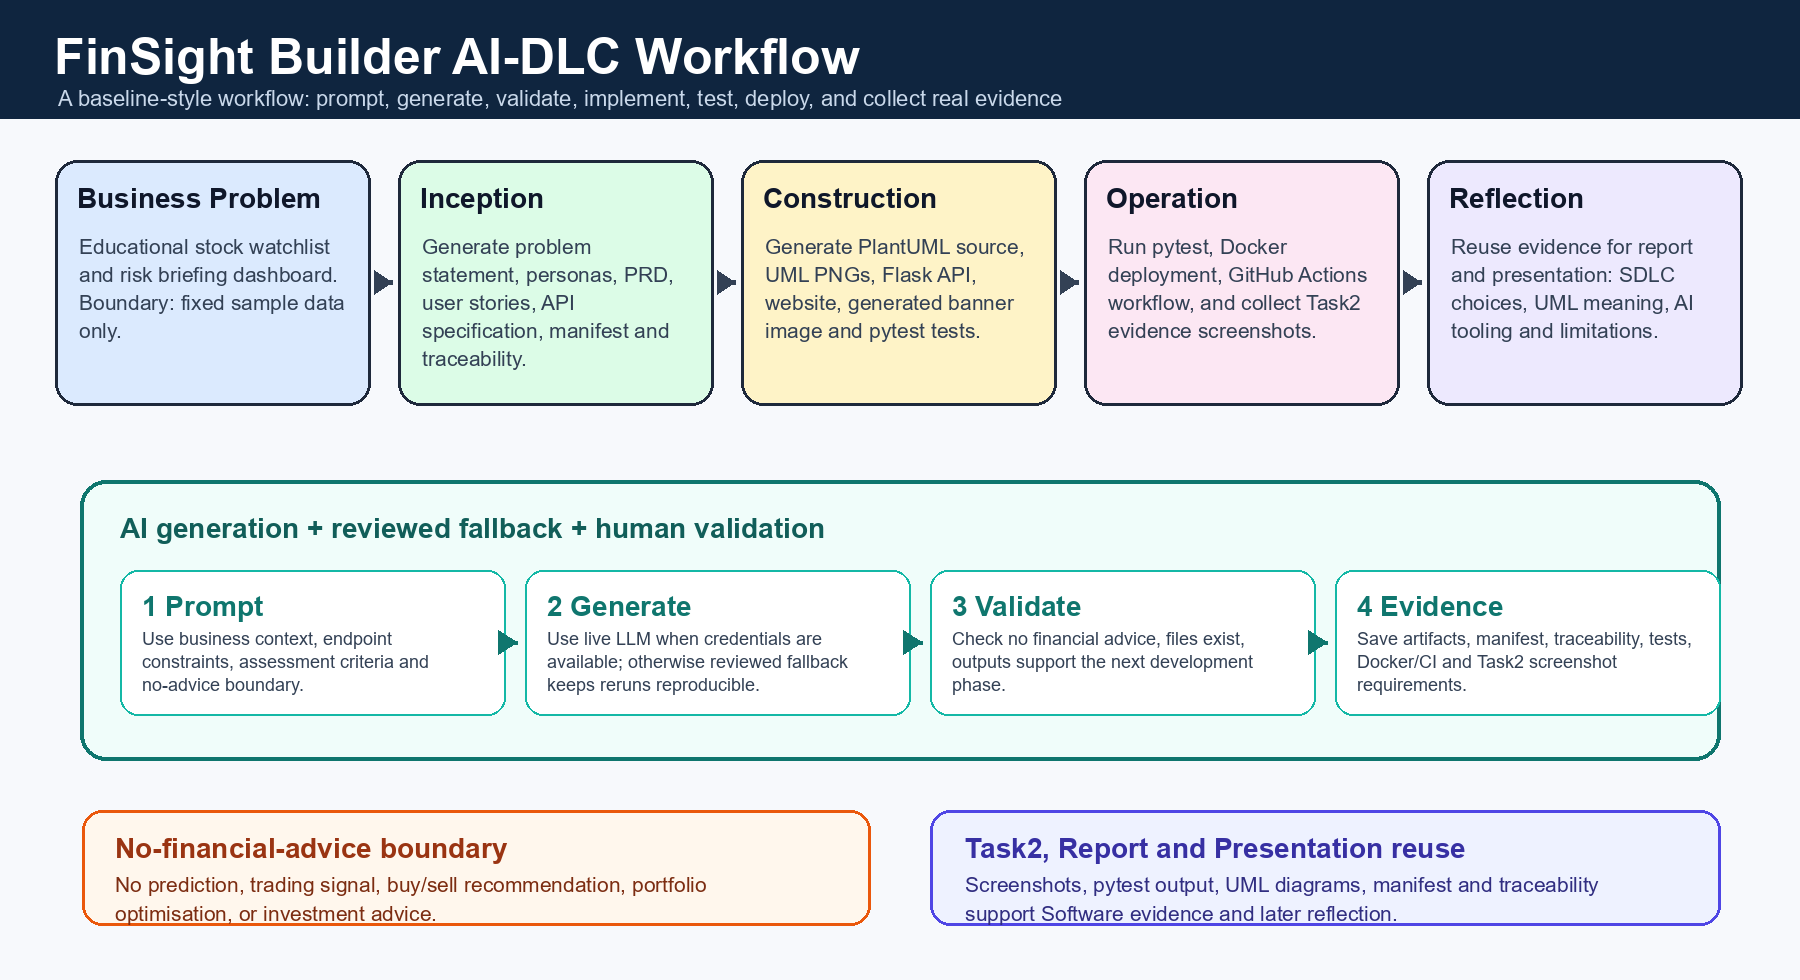

In [111]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import Image as DisplayImage, Markdown, display

workflow_png = DIAGRAM_DIR / "finsight_builder_workflow.png"
w, h = 1800, 980
img = Image.new("RGB", (w, h), "#f7f9fc")
d = ImageDraw.Draw(img)

def load_font(size, bold=False):
    candidates = ["arialbd.ttf" if bold else "arial.ttf", "segoeuib.ttf" if bold else "segoeui.ttf"]
    for name in candidates:
        try:
            return ImageFont.truetype(name, size)
        except OSError:
            pass
    return ImageFont.load_default()

title_font = load_font(50, True)
subtitle_font = load_font(22)
phase_font = load_font(28, True)
body_font = load_font(21)
small_font = load_font(18)

def wrap_text(text, font, max_width):
    lines = []
    for raw in text.split("\n"):
        words = raw.split()
        line = ""
        for word in words:
            candidate = (line + " " + word).strip()
            if d.textbbox((0, 0), candidate, font=font)[2] <= max_width:
                line = candidate
            else:
                if line:
                    lines.append(line)
                line = word
        lines.append(line)
    return lines

def draw_wrapped(x, y, text, font, fill, max_width, line_gap=8):
    for line in wrap_text(text, font, max_width):
        d.text((x, y), line, fill=fill, font=font)
        y += font.size + line_gap if hasattr(font, "size") else 24
    return y

# Header
d.rectangle((0, 0, w, 118), fill="#0f253f")
d.text((54, 28), "FinSight Builder AI-DLC Workflow", fill="white", font=title_font)
d.text((58, 86), "A baseline-style workflow: prompt, generate, validate, implement, test, deploy, and collect real evidence", fill="#c9d8ea", font=subtitle_font)

# Phase cards
phases = [
    ("Business Problem", "Educational stock watchlist and risk briefing dashboard. Boundary: fixed sample data only.", "#dbeafe"),
    ("Inception", "Generate problem statement, personas, PRD, user stories, API specification, manifest and traceability.", "#dcfce7"),
    ("Construction", "Generate PlantUML source, UML PNGs, Flask API, website, generated banner image and pytest tests.", "#fef3c7"),
    ("Operation", "Run pytest, Docker deployment, GitHub Actions workflow, and collect Task2 evidence screenshots.", "#fce7f3"),
    ("Reflection", "Reuse evidence for report and presentation: SDLC choices, UML meaning, AI tooling and limitations.", "#ede9fe"),
]
start_x, top, box_w, box_h, gap = 55, 160, 315, 245, 28
for idx, (title, body, color) in enumerate(phases):
    x = start_x + idx * (box_w + gap)
    d.rounded_rectangle((x, top, x + box_w, top + box_h), radius=22, fill=color, outline="#1e293b", width=3)
    d.text((x + 22, top + 22), title, fill="#0f172a", font=phase_font)
    draw_wrapped(x + 24, top + 74, body, body_font, "#334155", box_w - 48, 7)
    if idx < len(phases) - 1:
        ax = x + box_w
        ay = top + box_h // 2
        d.line((ax + 4, ay, ax + gap - 6, ay), fill="#334155", width=5)
        d.polygon([(ax + gap - 6, ay), (ax + gap - 24, ay - 12), (ax + gap - 24, ay + 12)], fill="#334155")

# AI/human validation lane
d.rounded_rectangle((80, 480, 1720, 760), radius=26, outline="#0f766e", width=4, fill="#f0fdfa")
d.text((120, 512), "AI generation + reviewed fallback + human validation", fill="#115e59", font=phase_font)
loop_items = [
    ("1 Prompt", "Use business context, endpoint constraints, assessment criteria and no-advice boundary."),
    ("2 Generate", "Use live LLM when credentials are available; otherwise reviewed fallback keeps reruns reproducible."),
    ("3 Validate", "Check no financial advice, files exist, outputs support the next development phase."),
    ("4 Evidence", "Save artifacts, manifest, traceability, tests, Docker/CI and Task2 screenshot requirements."),
]
item_w = 385
for i, (head, body) in enumerate(loop_items):
    x = 120 + i * 405
    d.rounded_rectangle((x, 570, x + item_w, 715), radius=18, fill="#ffffff", outline="#14b8a6", width=2)
    d.text((x + 22, 590), head, fill="#0f766e", font=phase_font)
    draw_wrapped(x + 22, 628, body, small_font, "#334155", item_w - 44, 5)
    if i < len(loop_items) - 1:
        d.line((x + item_w + 8, 642, x + 397, 642), fill="#0f766e", width=4)
        d.polygon([(x + 397, 642), (x + 378, 630), (x + 378, 654)], fill="#0f766e")

# Footer boundary/evidence bands
d.rounded_rectangle((82, 810, 870, 925), radius=20, fill="#fff7ed", outline="#ea580c", width=3)
d.text((115, 832), "No-financial-advice boundary", fill="#9a3412", font=phase_font)
draw_wrapped(115, 872, "No prediction, trading signal, buy/sell recommendation, portfolio optimisation, or investment advice.", body_font, "#7c2d12", 700)

d.rounded_rectangle((930, 810, 1720, 925), radius=20, fill="#eef2ff", outline="#4f46e5", width=3)
d.text((965, 832), "Task2, Report and Presentation reuse", fill="#3730a3", font=phase_font)
draw_wrapped(965, 872, "Screenshots, pytest output, UML diagrams, manifest and traceability support Software evidence and later reflection.", body_font, "#312e81", 700)

img.save(workflow_png)
display(Markdown(f"Workflow diagram saved to `{workflow_png.relative_to(REPO_ROOT)}`."))
display(DisplayImage(filename=str(workflow_png)))


## Artifact Dependency Map

The notebook is a meta-software development workflow: each artifact becomes input evidence for the next phase rather than a disconnected checklist item.


In [112]:
from IPython.display import Markdown, display

dependency_chain = [
    "Business Problem", "Problem Statement", "Personas", "PRD / Requirements", "User Stories",
    "API Specification", "UML", "Flask API + Website", "Generated Image", "Tests", "Docker / CI",
    "Task2 Evidence", "Report / Presentation Reflection"
]
display(Markdown("### Development Evidence Chain\n\n" + " -> ".join(f"**{item}**" for item in dependency_chain)))
print("Each stage consumes the previous artifact and produces evidence for the next development decision.")


### Development Evidence Chain

**Business Problem** -> **Problem Statement** -> **Personas** -> **PRD / Requirements** -> **User Stories** -> **API Specification** -> **UML** -> **Flask API + Website** -> **Generated Image** -> **Tests** -> **Docker / CI** -> **Task2 Evidence** -> **Report / Presentation Reflection**

Each stage consumes the previous artifact and produces evidence for the next development decision.


# Phase 1: Inception

The Inception phase follows the course practical mechanism: each artifact starts with a prompt, uses `get_completion(...)` when a client is available, cleans and validates the result, and falls back to a reviewed deterministic version when no API key or client is available. This gives visible AI-generation evidence without making the notebook dependent on live LLM credits.


## 1. Intent and Business Problem

In [113]:
business_problem = '''
Generate a reproducible AI-assisted software project named FinSight Builder. The notebook must automatically create SDLC documentation, UML diagrams, Flask API code, a website, a generated image, tests, Docker deployment files, and GitHub Actions CI configuration. The generated application is an educational stock watchlist and risk briefing dashboard using fixed sample data only. It must not predict prices, recommend trades, or provide financial advice.
'''.strip()

business_problem_prompt = f'''
You are supporting the DTS114TC Software Component. Expand this intent into a bounded business problem suitable for AI-DLC documentation and implementation. Preserve the constraints: no stock prediction, no buy/sell advice, no investment recommendation, and no mandatory live financial API dependency.
Intent: {business_problem}
'''.strip()

print(business_problem)
print("\nPrompt used for AI generation/human review:\n", business_problem_prompt)

Generate a reproducible AI-assisted software project named FinSight Builder. The notebook must automatically create SDLC documentation, UML diagrams, Flask API code, a website, a generated image, tests, Docker deployment files, and GitHub Actions CI configuration. The generated application is an educational stock watchlist and risk briefing dashboard using fixed sample data only. It must not predict prices, recommend trades, or provide financial advice.

Prompt used for AI generation/human review:
 You are supporting the DTS114TC Software Component. Expand this intent into a bounded business problem suitable for AI-DLC documentation and implementation. Preserve the constraints: no stock prediction, no buy/sell advice, no investment recommendation, and no mandatory live financial API dependency.
Intent: Generate a reproducible AI-assisted software project named FinSight Builder. The notebook must automatically create SDLC documentation, UML diagrams, Flask API code, a website, a generat

#### 1) AI generated - Problem statement

This cell expands the business problem using the LLM helper when available. If the client is unavailable, the artifact is explicitly produced from a reviewed fallback.


In [114]:
problem_statement_prompt = f"""
You are an AI software engineering assistant. Convert the following business intent into a concise coursework problem statement.

Constraints:
- The generated application is an educational stock watchlist and risk briefing dashboard.
- Do not include stock prediction, buy/sell/hold advice, trading automation, or financial advice.
- Mention SDLC documentation, UML, Flask API, website, generated image, tests, Docker, and CI workflow.
- Output Markdown with the heading "# Problem Statement".

Business intent:
{business_problem}
""".strip()

problem_statement_fallback = """# Problem Statement

FinSight Builder addresses a coursework scenario in which a student developer needs to demonstrate an AI-powered software engineering workflow, not only a finished Flask application. The target generated product is an educational stock watchlist and risk briefing dashboard for learner users who want to compare sample companies and understand risk factors in plain language. A coursework marker is also a primary user because the notebook must make the generation process, validation decisions, and deployment evidence inspectable.

The system must transform a bounded business problem into SDLC documentation, personas, a PRD, user stories, an API specification, UML diagrams, Flask API and website code, a generated visual asset, pytest tests, Docker deployment files, and GitHub Actions workflow configuration. Each artifact should be traceable to the next phase so the project reads as a coherent AI-driven lifecycle.

The financial domain is deliberately constrained. The application uses fixed educational sample data only. It must not predict prices, recommend buy/sell/hold decisions, automate trading, allocate portfolios, or present itself as financial advice.
"""

problem_statement, problem_statement_source = llm_or_fallback(problem_statement_prompt, problem_statement_fallback, language="markdown")
if not problem_statement.lstrip().startswith("#"):
    problem_statement = "# Problem Statement\n\n" + problem_statement
save_text_artifact(ARTIFACTS / "problem_statement.md", problem_statement, problem_statement_source)
print("Problem statement source:", problem_statement_source)
print(problem_statement[:900])

record_generation("problem_statement", problem_statement_source, ["Markdown heading present", "No prediction/trading/advice scope", "Mentions generated software evidence"], ARTIFACTS / "problem_statement.md", "Grounds personas and PRD", ["documentation generation", "notebook professional structure", "AI-specific tooling"])


Saved Task1\artifacts\problem_statement.md (reviewed fallback)
Problem statement source: reviewed fallback
# Problem Statement

FinSight Builder addresses a coursework scenario in which a student developer needs to demonstrate an AI-powered software engineering workflow, not only a finished Flask application. The target generated product is an educational stock watchlist and risk briefing dashboard for learner users who want to compare sample companies and understand risk factors in plain language. A coursework marker is also a primary user because the notebook must make the generation process, validation decisions, and deployment evidence inspectable.

The system must transform a bounded business problem into SDLC documentation, personas, a PRD, user stories, an API specification, UML diagrams, Flask API and website code, a generated visual asset, pytest tests, Docker deployment files, and GitHub Actions workflow configuration. Each artifact should be traceable to the next phase so th

{'artifact': 'problem_statement',
 'source_type': 'reviewed fallback',
 'output_path': 'Task1\\artifacts\\problem_statement.md',
 'validation_checks': ['Markdown heading present',
  'No prediction/trading/advice scope',
  'Mentions generated software evidence'],
 'next_stage_use': 'Grounds personas and PRD',
 'software_marking_criteria': ['documentation generation',
  'notebook professional structure',
  'AI-specific tooling']}

#### 2) AI generated - Personas

Personas are used as in Agile development to clarify who benefits from the generated software and what evidence each stakeholder needs.

In [115]:
personas_prompt = f"""
You are an Agile analyst. Create concise personas for FinSight Builder using the problem statement below.

Required personas:
1. Student Developer
2. Learner User
3. Coursework Marker

For each persona include needs, goals, pain points, and the related software evidence or requirement.
Output Markdown with the heading "# Personas".

Problem statement:
{problem_statement}
""".strip()

personas_fallback = """# Personas

## Student Developer
- Goals: build a reproducible AI software engineering notebook, show how prompts become artifacts, and produce runnable Flask/Docker/CI evidence.
- Frustrations: opaque generated code, static documentation that does not connect to tests, and deployment evidence that is hard to reproduce.
- Success criteria: every generated artifact has a source, validation checks, output path, and next-phase purpose; tests pass locally; Docker and CI files are present.
- Linked requirements: documentation generation, UML generation, Flask implementation, pytest, Docker, CI workflow, Task2 evidence.

## Learner User
- Goals: open a simple dashboard, review sample stock risk briefings, add supported tickers to a watchlist, and submit feedback.
- Frustrations: confusing finance dashboards, hidden assumptions, and advice-like wording.
- Success criteria: visible non-advice disclaimer, clear sample data, validation feedback for unsupported tickers, and readable risk summaries.
- Linked requirements: website home page, `/api/stocks`, `/api/stocks/<ticker>`, `/api/watchlist`, `/api/feedback`, `/api/risk-summary`.

## Coursework Marker
- Goals: evaluate whether the project demonstrates AI-specific tooling, SDLC structure, UML, testing, workflow, version control, and deployment.
- Frustrations: notebooks that only paste final outputs, missing traceability, missing screenshots, or generated files that cannot be rerun.
- Success criteria: notebook follows a visible AI-DLC chain, generated artifacts are saved, tests pass, CI/Docker configuration exists, and Task2 evidence is named clearly.
- Linked requirements: generation manifest, traceability matrix, rubric coverage matrix, screenshots, test output, and clean packaging checklist.
"""

personas, personas_source = llm_or_fallback(personas_prompt, personas_fallback, language="markdown")
if "# Personas" not in personas:
    personas = "# Personas\n\n" + personas
save_text_artifact(ARTIFACTS / "personas.md", personas, personas_source)
print("Personas source:", personas_source)
print(personas[:900])

record_generation("personas", personas_source, ["Three stakeholders present", "Goals/frustrations/success criteria included", "Linked to requirements"], ARTIFACTS / "personas.md", "Informs PRD priorities and user stories", ["documentation generation", "notebook professional structure", "AI-specific tooling"])


Saved Task1\artifacts\personas.md (reviewed fallback)
Personas source: reviewed fallback
# Personas

## Student Developer
- Goals: build a reproducible AI software engineering notebook, show how prompts become artifacts, and produce runnable Flask/Docker/CI evidence.
- Frustrations: opaque generated code, static documentation that does not connect to tests, and deployment evidence that is hard to reproduce.
- Success criteria: every generated artifact has a source, validation checks, output path, and next-phase purpose; tests pass locally; Docker and CI files are present.
- Linked requirements: documentation generation, UML generation, Flask implementation, pytest, Docker, CI workflow, Task2 evidence.

## Learner User
- Goals: open a simple dashboard, review sample stock risk briefings, add supported tickers to a watchlist, and submit feedback.
- Frustrations: confusing finance dashboards, hidden assumptions, and advice-like wording.
- Success criteria: visible non-advice di


{'artifact': 'personas',
 'source_type': 'reviewed fallback',
 'output_path': 'Task1\\artifacts\\personas.md',
 'validation_checks': ['Three stakeholders present',
  'Goals/frustrations/success criteria included',
  'Linked to requirements'],
 'next_stage_use': 'Informs PRD priorities and user stories',
 'software_marking_criteria': ['documentation generation',
  'notebook professional structure',
  'AI-specific tooling']}

#### 3) AI generated - PRD and requirements

The PRD makes the project boundary explicit and maps assessment needs into implementable requirements.

In [116]:
prd_prompt = f"""
You are a product owner writing a Product Requirements Document for FinSight Builder.

Create a compact PRD in Markdown with these sections:
- Overview
- Goals
- Non-goals
- Functional requirements
- Non-functional requirements
- Assessment evidence requirements

The application must use fixed educational sample data only and must not provide financial advice.

Problem statement:
{problem_statement}

Personas:
{personas}
""".strip()

prd_fallback = """# Product Requirements Document

## Overview
FinSight Builder is an AI-powered meta-software development notebook that generates a Flask API and website for a sample stock watchlist and educational risk briefing dashboard. The notebook itself is the main software engineering artifact: it demonstrates how prompts, LLM/fallback generation, human validation, UML, implementation, tests, CI/CD, Docker, and evidence collection connect.

## Functional requirements
- FR-001: Generate and save a problem statement, personas, PRD, user stories, and API specification.
- FR-002: Generate and save PlantUML source and PNG UML evidence.
- FR-003: Provide a Flask API with `/health`, `/api/stocks`, `/api/stocks/<ticker>`, `/api/watchlist`, `/api/feedback`, `/api/risk-summary`, and `/`.
- FR-004: Provide a website that displays stock cards, risk summary, generated banner image, watchlist form, feedback form, and disclaimer.
- FR-005: Generate pytest tests for success and validation/error paths.
- FR-006: Generate Dockerfile, Docker Compose, and GitHub Actions workflow files.

## Non-functional requirements
- NFR-001: The notebook must rerun without exposing API keys.
- NFR-002: The generated Flask application must run locally and in Docker on port 5005.
- NFR-003: The project must avoid financial advice, prediction, and trading automation.
- NFR-004: The final software package must contain a clean Task1/Task2 structure.

## Constraints and assumptions
- Uses fixed educational sample stock data.
- LLM generation is preferred when credentials are available; reviewed fallback keeps the notebook reproducible.
- External image and PlantUML rendering services are optional, not required for successful reruns.

## Risks
- R1: API key or network unavailable; mitigation: reviewed fallback outputs and local image fallback.
- R2: PlantUML renderer unavailable; mitigation: local rendering attempts followed by explicit fallback status.
- R3: Submission zip pollution; mitigation: clean packaging checklist.

## Acceptance criteria
- AC-001: Task1 contains exactly one notebook.
- AC-002: Required generated artifacts exist under Task1/artifacts.
- AC-003: `python -m pytest Task1/artifacts/app/tests` passes.
- AC-004: Docker and GitHub Actions files exist and include pytest plus Docker build workflow.
- AC-005: Task2 evidence requirements are listed and missing evidence is clearly identified.
"""

prd, prd_source = llm_or_fallback(prd_prompt, prd_fallback, language="markdown")
if "#" not in prd[:20]:
    prd = "# Product Requirements Document\n\n" + prd
save_text_artifact(ARTIFACTS / "prd.md", prd, prd_source)
print("PRD source:", prd_source)
print(prd[:1100])

record_generation("prd", prd_source, ["Functional and non-functional requirements present", "Constraints, assumptions, risks, acceptance criteria present", "No financial advice scope"], ARTIFACTS / "prd.md", "Drives user stories, API specification, and implementation scope", ["documentation generation", "notebook professional structure", "AI-specific tooling"])


Saved Task1\artifacts\prd.md (reviewed fallback)
PRD source: reviewed fallback
# Product Requirements Document

## Overview
FinSight Builder is an AI-powered meta-software development notebook that generates a Flask API and website for a sample stock watchlist and educational risk briefing dashboard. The notebook itself is the main software engineering artifact: it demonstrates how prompts, LLM/fallback generation, human validation, UML, implementation, tests, CI/CD, Docker, and evidence collection connect.

## Functional requirements
- FR-001: Generate and save a problem statement, personas, PRD, user stories, and API specification.
- FR-002: Generate and save PlantUML source and PNG UML evidence.
- FR-003: Provide a Flask API with `/health`, `/api/stocks`, `/api/stocks/<ticker>`, `/api/watchlist`, `/api/feedback`, `/api/risk-summary`, and `/`.
- FR-004: Provide a website that displays stock cards, risk summary, generated banner image, watchlist form, feedback form, and disclaimer.
- 

{'artifact': 'prd',
 'source_type': 'reviewed fallback',
 'output_path': 'Task1\\artifacts\\prd.md',
 'validation_checks': ['Functional and non-functional requirements present',
  'Constraints, assumptions, risks, acceptance criteria present',
  'No financial advice scope'],
 'next_stage_use': 'Drives user stories, API specification, and implementation scope',
 'software_marking_criteria': ['documentation generation',
  'notebook professional structure',
  'AI-specific tooling']}

#### 4) AI generated - User stories

In [117]:
user_stories_prompt = f"""
You are an Agile business analyst. Generate user stories for FinSight Builder from the PRD.

Return ONLY valid JSON: a list of objects with keys id, role, story, and acceptance_criteria.
Include stories for:
- learner dashboard and generated image
- watchlist validation
- feedback submission
- coursework marker evidence for tests, CI/CD, Docker, and deployment

PRD:
{prd}
""".strip()

user_stories_fallback = [
    {"id": "US-001", "role": "learner user", "story": "I want to open the dashboard so that I can review educational stock risk briefings with a visible disclaimer.", "requirement": "FR-004", "api_endpoint": "/ and /api/stocks", "test_case": "test_index_page_and_generated_image_reference; test_stocks_have_required_fields", "acceptance_criteria": ["Home page returns 200.", "Generated banner is referenced in index.html.", "Stock cards include ticker, mock price, risk level, and briefing."]},
    {"id": "US-002", "role": "learner user", "story": "I want to inspect one supported ticker so that I can focus on a single educational briefing.", "requirement": "FR-003", "api_endpoint": "/api/stocks/<ticker>", "test_case": "test_stock_detail_and_unknown_ticker", "acceptance_criteria": ["Known ticker returns 200.", "Unknown ticker returns 404.", "Response includes disclaimer."]},
    {"id": "US-003", "role": "learner user", "story": "I want to add a supported ticker to my watchlist so that I can track examples I am studying.", "requirement": "FR-003", "api_endpoint": "/api/watchlist", "test_case": "test_watchlist_validation_and_success", "acceptance_criteria": ["Missing ticker returns 400.", "Known ticker returns 201.", "Unknown ticker returns 404."]},
    {"id": "US-004", "role": "learner user", "story": "I want to submit feedback so that the app demonstrates validated form handling.", "requirement": "FR-003", "api_endpoint": "/api/feedback", "test_case": "test_feedback_validation_and_success; test_feedback_get_returns_submitted_items", "acceptance_criteria": ["Missing fields return 400.", "Valid feedback returns 201.", "GET feedback returns the submitted item."]},
    {"id": "US-005", "role": "coursework marker", "story": "I want to inspect tests, Docker, CI, and evidence outputs so that I can assess the software workflow.", "requirement": "FR-005/FR-006", "api_endpoint": "N/A", "test_case": "test_risk_summary_shape plus CI pytest command", "acceptance_criteria": ["pytest tests pass.", "CI workflow runs pytest and Docker build.", "Task2 evidence file names are listed."]}
]

user_stories_raw, user_stories_source = llm_or_fallback(user_stories_prompt, json.dumps(user_stories_fallback, indent=2), language="json", min_length=40)
try:
    user_stories = json.loads(user_stories_raw)
    assert isinstance(user_stories, list)
    for story in user_stories:
        assert {"id", "role", "story", "acceptance_criteria"} <= set(story)
except Exception as exc:
    print("User story JSON validation failed; using reviewed fallback:", exc)
    user_stories = user_stories_fallback
    user_stories_source = "reviewed fallback after validation"

(ARTIFACTS / "user_stories.json").write_text(json.dumps(user_stories, indent=2), encoding="utf-8")
print(f"Saved {(ARTIFACTS / 'user_stories.json').relative_to(REPO_ROOT)} ({user_stories_source})")
print(json.dumps(user_stories, indent=2)[:1200])

record_generation("user_stories", user_stories_source, ["Valid JSON list", "Acceptance criteria present", "Stories map to endpoints and tests"], ARTIFACTS / "user_stories.json", "Maps requirements into API and pytest coverage", ["documentation generation", "notebook professional structure", "testing practices", "AI-specific tooling"])


Saved Task1\artifacts\user_stories.json (reviewed fallback)
[
  {
    "id": "US-001",
    "role": "learner user",
    "story": "I want to open the dashboard so that I can review educational stock risk briefings with a visible disclaimer.",
    "requirement": "FR-004",
    "api_endpoint": "/ and /api/stocks",
    "test_case": "test_index_page_and_generated_image_reference; test_stocks_have_required_fields",
    "acceptance_criteria": [
      "Home page returns 200.",
      "Generated banner is referenced in index.html.",
      "Stock cards include ticker, mock price, risk level, and briefing."
    ]
  },
  {
    "id": "US-002",
    "role": "learner user",
    "story": "I want to inspect one supported ticker so that I can focus on a single educational briefing.",
    "requirement": "FR-003",
    "api_endpoint": "/api/stocks/<ticker>",
    "test_case": "test_stock_detail_and_unknown_ticker",
    "acceptance_criteria": [
      "Known ticker returns 200.",
      "Unknown ticker returns 404.

{'artifact': 'user_stories',
 'source_type': 'reviewed fallback',
 'output_path': 'Task1\\artifacts\\user_stories.json',
 'validation_checks': ['Valid JSON list',
  'Acceptance criteria present',
  'Stories map to endpoints and tests'],
 'next_stage_use': 'Maps requirements into API and pytest coverage',
 'software_marking_criteria': ['documentation generation',
  'notebook professional structure',
  'testing practices',
  'AI-specific tooling']}

#### 5) AI generated - API specification

In [118]:
api_spec_prompt = f"""
You are a backend API designer. Create a compact Markdown API specification for the FinSight Builder Flask application.

Required endpoints:
- GET /health
- GET /api/stocks
- GET /api/stocks/<ticker>
- GET and POST /api/watchlist
- GET and POST /api/feedback
- GET /api/risk-summary
- GET /

For each endpoint include purpose, validation/error behavior where relevant, and note that financial content is educational sample data only.

PRD:
{prd}

User stories:
{json.dumps(user_stories, indent=2)}
""".strip()

api_spec_fallback = """# API Specification

Base URL: `http://127.0.0.1:5005`

| Endpoint | Method | Story IDs | Test case | Purpose | Validation / response notes |
|---|---|---|---|---|---|
| `/` | GET | US-001 | `test_index_page_and_generated_image_reference` | Serve generated dashboard website | Returns 200 and references `static/generated_market_banner.png`. |
| `/health` | GET | US-005 | `test_health_endpoint` | Deployment health check | Returns service status and disclaimer. |
| `/api/stocks` | GET | US-001 | `test_stocks_have_required_fields` | Return educational sample stock list | Includes ticker, name, sector, mock_price, risk_level, and briefing. |
| `/api/stocks/<ticker>` | GET | US-002 | `test_stock_detail_and_unknown_ticker` | Return one educational stock briefing | Known ticker returns 200; unknown ticker returns 404. |
| `/api/watchlist` | GET | US-003 | covered by watchlist integration path | Return in-memory watchlist | Returns selected sample stocks and ticker list. |
| `/api/watchlist` | POST | US-003 | `test_watchlist_validation_and_success` | Add supported ticker to watchlist | Missing ticker returns 400; unsupported ticker returns 404; valid ticker returns 201. |
| `/api/feedback` | GET | US-004 | `test_feedback_get_returns_submitted_items` | Return submitted feedback items | Returns list and count after POST. |
| `/api/feedback` | POST | US-004 | `test_feedback_validation_and_success` | Submit feedback | Requires name, message, and rating; rating must be 1-5. |
| `/api/risk-summary` | GET | US-001/US-005 | `test_risk_summary_shape` | Return counts by risk level | Returns low, medium, and high keys. |

All financial content is fixed educational sample data only. The API does not provide investment recommendations, predictions, trading automation, or financial advice.
"""

api_spec, api_spec_source = llm_or_fallback(api_spec_prompt, api_spec_fallback, language="markdown")
required_endpoint_tokens = ["/health", "/api/stocks", "/api/watchlist", "/api/feedback", "/api/risk-summary"]
if not all(token in api_spec for token in required_endpoint_tokens):
    print("API spec validation failed; using reviewed fallback.")
    api_spec = api_spec_fallback.strip() + "\n"
    api_spec_source = "reviewed fallback after validation"
save_text_artifact(ARTIFACTS / "api_spec.md", api_spec, api_spec_source)
print("API spec source:", api_spec_source)
print(api_spec[:1200])

record_generation("api_spec", api_spec_source, ["All required endpoints present", "Validation behavior documented", "Mapped to story IDs and tests"], ARTIFACTS / "api_spec.md", "Informs Flask routes and API tests", ["documentation generation", "notebook professional structure", "testing practices", "deployment evidence", "AI-specific tooling"])


Saved Task1\artifacts\api_spec.md (reviewed fallback)
API spec source: reviewed fallback
# API Specification

Base URL: `http://127.0.0.1:5005`

| Endpoint | Method | Story IDs | Test case | Purpose | Validation / response notes |
|---|---|---|---|---|---|
| `/` | GET | US-001 | `test_index_page_and_generated_image_reference` | Serve generated dashboard website | Returns 200 and references `static/generated_market_banner.png`. |
| `/health` | GET | US-005 | `test_health_endpoint` | Deployment health check | Returns service status and disclaimer. |
| `/api/stocks` | GET | US-001 | `test_stocks_have_required_fields` | Return educational sample stock list | Includes ticker, name, sector, mock_price, risk_level, and briefing. |
| `/api/stocks/<ticker>` | GET | US-002 | `test_stock_detail_and_unknown_ticker` | Return one educational stock briefing | Known ticker returns 200; unknown ticker returns 404. |
| `/api/watchlist` | GET | US-003 | covered by watchlist integration path | Return in-m

{'artifact': 'api_spec',
 'source_type': 'reviewed fallback',
 'output_path': 'Task1\\artifacts\\api_spec.md',
 'validation_checks': ['All required endpoints present',
  'Validation behavior documented',
  'Mapped to story IDs and tests'],
 'next_stage_use': 'Informs Flask routes and API tests',
 'software_marking_criteria': ['documentation generation',
  'notebook professional structure',
  'testing practices',
  'deployment evidence',
  'AI-specific tooling']}

## Traceability Matrix

The traceability matrix connects the AI-generated requirements to API endpoints, tests, and evidence files. This is the bridge from Inception artifacts to Construction and Operation.


In [119]:
from IPython.display import Markdown, display

traceability_rows = []
for story in user_stories:
    traceability_rows.append({
        "User Story ID": story.get("id", ""),
        "Requirement": story.get("requirement", ""),
        "API Endpoint": story.get("api_endpoint", ""),
        "Test Case": story.get("test_case", ""),
        "Evidence File": "Task1/artifacts/app/tests/test_app.py" if story.get("test_case") else "Task1/artifacts/user_stories.json",
    })
traceability_md = "# Traceability Matrix\n\n| User Story ID | Requirement | API Endpoint | Test Case | Evidence File |\n|---|---|---|---|---|\n"
for row in traceability_rows:
    traceability_md += f"| {row['User Story ID']} | {row['Requirement']} | `{row['API Endpoint']}` | `{row['Test Case']}` | `{row['Evidence File']}` |\n"
(ARTIFACTS / "traceability_matrix.md").write_text(traceability_md, encoding="utf-8")
display(Markdown(traceability_md))
print("Traceability matrix saved:", (ARTIFACTS / "traceability_matrix.md").relative_to(REPO_ROOT))


# Traceability Matrix

| User Story ID | Requirement | API Endpoint | Test Case | Evidence File |
|---|---|---|---|---|
| US-001 | FR-004 | `/ and /api/stocks` | `test_index_page_and_generated_image_reference; test_stocks_have_required_fields` | `Task1/artifacts/app/tests/test_app.py` |
| US-002 | FR-003 | `/api/stocks/<ticker>` | `test_stock_detail_and_unknown_ticker` | `Task1/artifacts/app/tests/test_app.py` |
| US-003 | FR-003 | `/api/watchlist` | `test_watchlist_validation_and_success` | `Task1/artifacts/app/tests/test_app.py` |
| US-004 | FR-003 | `/api/feedback` | `test_feedback_validation_and_success; test_feedback_get_returns_submitted_items` | `Task1/artifacts/app/tests/test_app.py` |
| US-005 | FR-005/FR-006 | `N/A` | `test_risk_summary_shape plus CI pytest command` | `Task1/artifacts/app/tests/test_app.py` |


Traceability matrix saved: Task1\artifacts\traceability_matrix.md


## Human Validation Framework

Generated artifacts are not accepted blindly. Each artifact is checked against the project boundary, file evidence, next-phase use, and Software marking criteria.


In [120]:
human_validation_checks = [
    "No financial advice, buy/sell recommendation, prediction, trading signal, or portfolio optimisation",
    "Educational/demo scope is explicit",
    "Output file exists in the expected Task1/Task2 structure",
    "Artifact supports the next development phase",
    "Artifact links to at least one Software marking criterion",
]
validation_md = "| Validation check | Applied to generated artifacts |\n|---|---|\n" + "\n".join(
    f"| {check} | yes |" for check in human_validation_checks
)
display(Markdown(validation_md))
print("Human validation framework active for manifest records.")


| Validation check | Applied to generated artifacts |
|---|---|
| No financial advice, buy/sell recommendation, prediction, trading signal, or portfolio optimisation | yes |
| Educational/demo scope is explicit | yes |
| Output file exists in the expected Task1/Task2 structure | yes |
| Artifact supports the next development phase | yes |
| Artifact links to at least one Software marking criterion | yes |

Human validation framework active for manifest records.


# Phase 2: Construction

The Construction phase turns the requirements into design and implementation artifacts. This notebook writes both the UML evidence and the executable Flask project.

## 2.1 AI generated - UML diagrams

The UML stage follows the same generation mechanism: prompt the LLM for PlantUML when available, clean the output, validate the `@startuml` / `@enduml` boundary, then save `.puml` files. Rendering first attempts the course `render_plantuml_diagram` helper; a PIL fallback is used only if PlantUML rendering is unavailable or fails.


In [121]:
uml_prompt = f"""
You are a software architect. Generate two PlantUML diagrams for FinSight Builder.

Return JSON only with keys "use_case_diagram" and "sequence_diagram". Each value must be complete PlantUML source from @startuml to @enduml.

Requirements:
- Use case diagram: Student Developer, Learner User, Coursework Marker; include documentation, UML, Flask app, generated image, tests, Docker/CI, and evidence review.
- Sequence diagram: Learner opens website, website calls Flask API, API reads fixed sample data, API returns JSON with disclaimer, user submits watchlist or feedback.
- Do not include prediction or trading advice flows.

API spec:
{api_spec}
""".strip()

uml_fallback = {
    "use_case_diagram": """@startuml
left to right direction
title FinSight Builder Use Case Diagram
actor "Student Developer" as Developer
actor "Learner User" as Learner
actor "Coursework Marker" as Marker
rectangle "FinSight Builder" {
  usecase "Generate SDLC docs" as UC1
  usecase "Generate UML diagrams" as UC2
  usecase "Generate Flask API and website" as UC3
  usecase "Display generated image" as UC4
  usecase "View educational risk briefing" as UC5
  usecase "Add ticker to watchlist" as UC6
  usecase "Submit feedback" as UC7
  usecase "Run tests, Docker and CI" as UC8
  usecase "Review submission evidence" as UC9
}
Developer --> UC1
Developer --> UC2
Developer --> UC3
Developer --> UC4
Developer --> UC8
Learner --> UC5
Learner --> UC6
Learner --> UC7
Marker --> UC8
Marker --> UC9
@enduml""",
    "sequence_diagram": """@startuml
title FinSight Builder Stock Briefing Sequence
actor Learner
participant "Website" as Web
participant "Flask API" as API
database "Fixed Sample Stock Data" as Data
Learner -> Web: Open dashboard
Web -> API: GET /api/stocks
API -> Data: Read sample stocks
Data --> API: Stock records
API --> Web: JSON with educational disclaimer
Web --> Learner: Render generated banner, cards, forms, and risk summary
Learner -> Web: Submit ticker or feedback
Web -> API: POST /api/watchlist or /api/feedback
API -> Data: Validate supported ticker/input shape
API --> Web: Success or validation error
Web --> Learner: Show result
@enduml""",
}

uml_raw, uml_source = llm_or_fallback(uml_prompt, json.dumps(uml_fallback, indent=2), language="json", min_length=80)
try:
    uml_data = json.loads(uml_raw)
    use_case_diagram = clean_text_output(uml_data["use_case_diagram"], language="plantuml")
    sequence_diagram = clean_text_output(uml_data["sequence_diagram"], language="plantuml")
    assert use_case_diagram.strip().startswith("@startuml") and use_case_diagram.strip().endswith("@enduml")
    assert sequence_diagram.strip().startswith("@startuml") and sequence_diagram.strip().endswith("@enduml")
except Exception as exc:
    print("UML validation failed; using reviewed fallback:", exc)
    use_case_diagram = uml_fallback["use_case_diagram"]
    sequence_diagram = uml_fallback["sequence_diagram"]
    uml_source = "reviewed fallback after validation"

(DIAGRAM_DIR / "use_case_diagram.puml").write_text(use_case_diagram + "\n", encoding="utf-8")
(DIAGRAM_DIR / "sequence_diagram.puml").write_text(sequence_diagram + "\n", encoding="utf-8")
print("PlantUML sources written:", uml_source)
print("-", DIAGRAM_DIR / "use_case_diagram.puml")
print("-", DIAGRAM_DIR / "sequence_diagram.puml")


PlantUML sources written: reviewed fallback
- C:\Users\31075\Desktop\大二下\dts114\CW\2472811-Feiyu_Chen\Task1\artifacts\diagrams\use_case_diagram.puml
- C:\Users\31075\Desktop\大二下\dts114\CW\2472811-Feiyu_Chen\Task1\artifacts\diagrams\sequence_diagram.puml


use_case_diagram: professional deterministic fallback renderer; saved Task1\artifacts\diagrams\use_case_diagram.png
sequence_diagram: professional deterministic fallback renderer; saved Task1\artifacts\diagrams\sequence_diagram.png
Render status saved: Task1\artifacts\diagrams\render_status.json


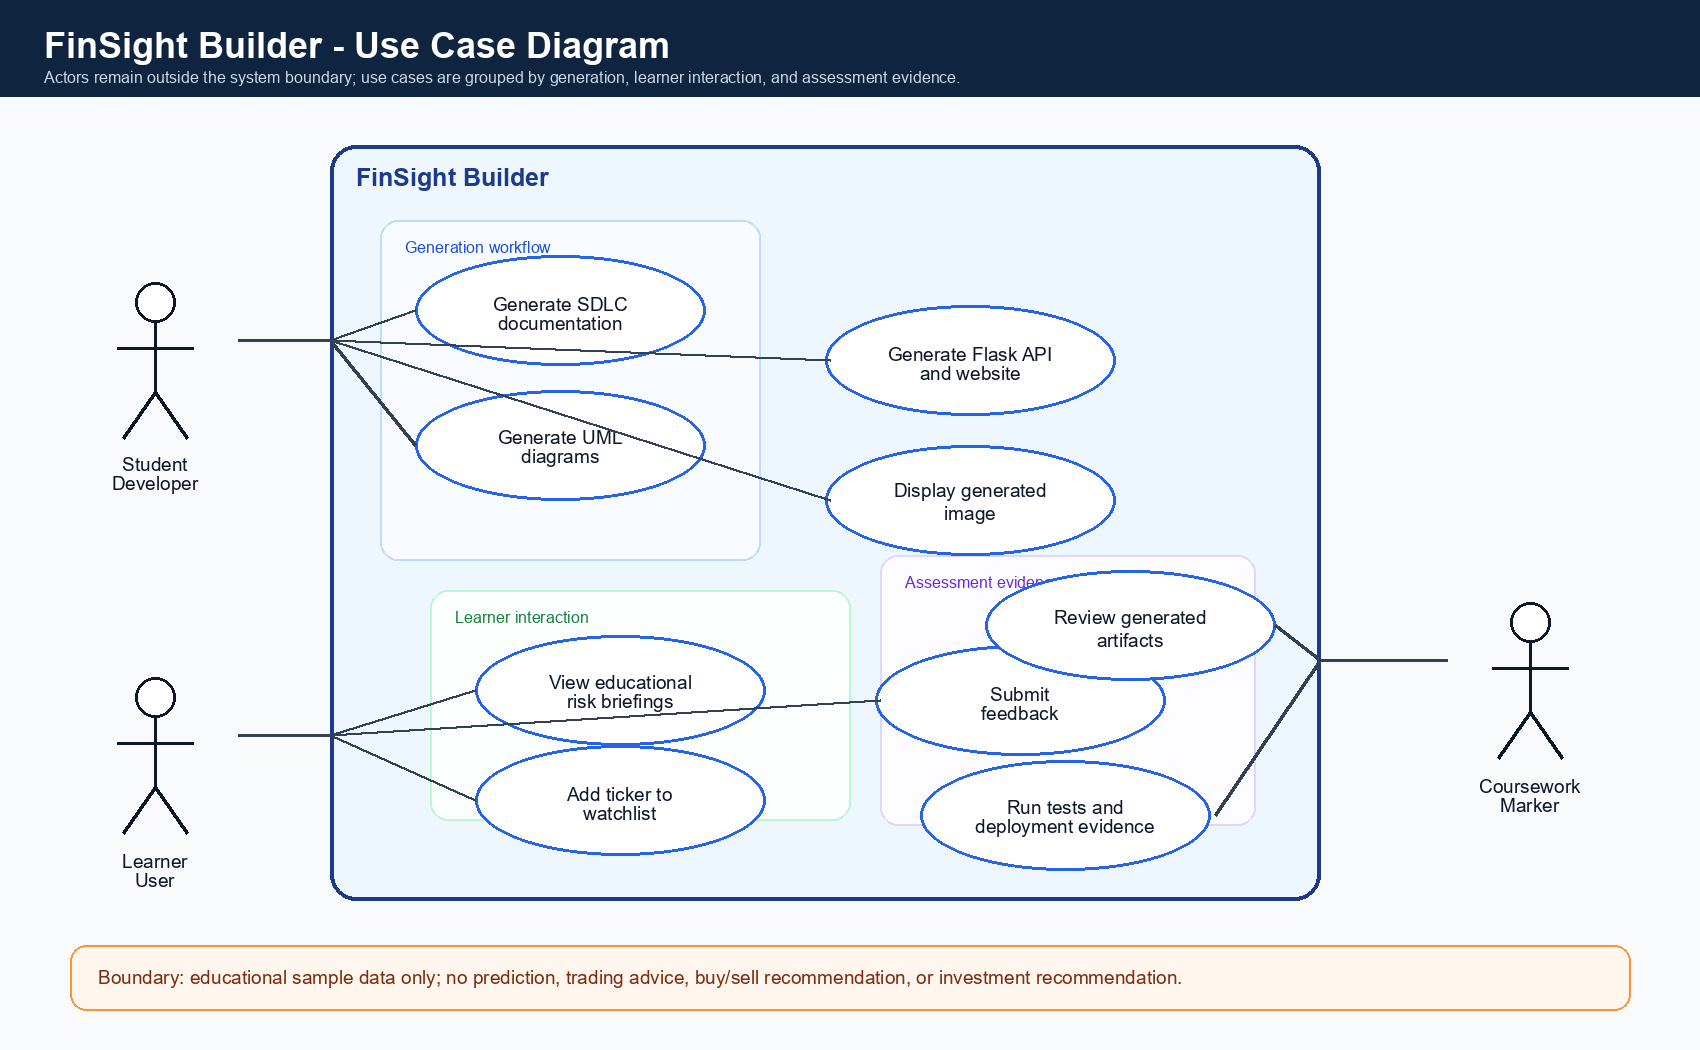

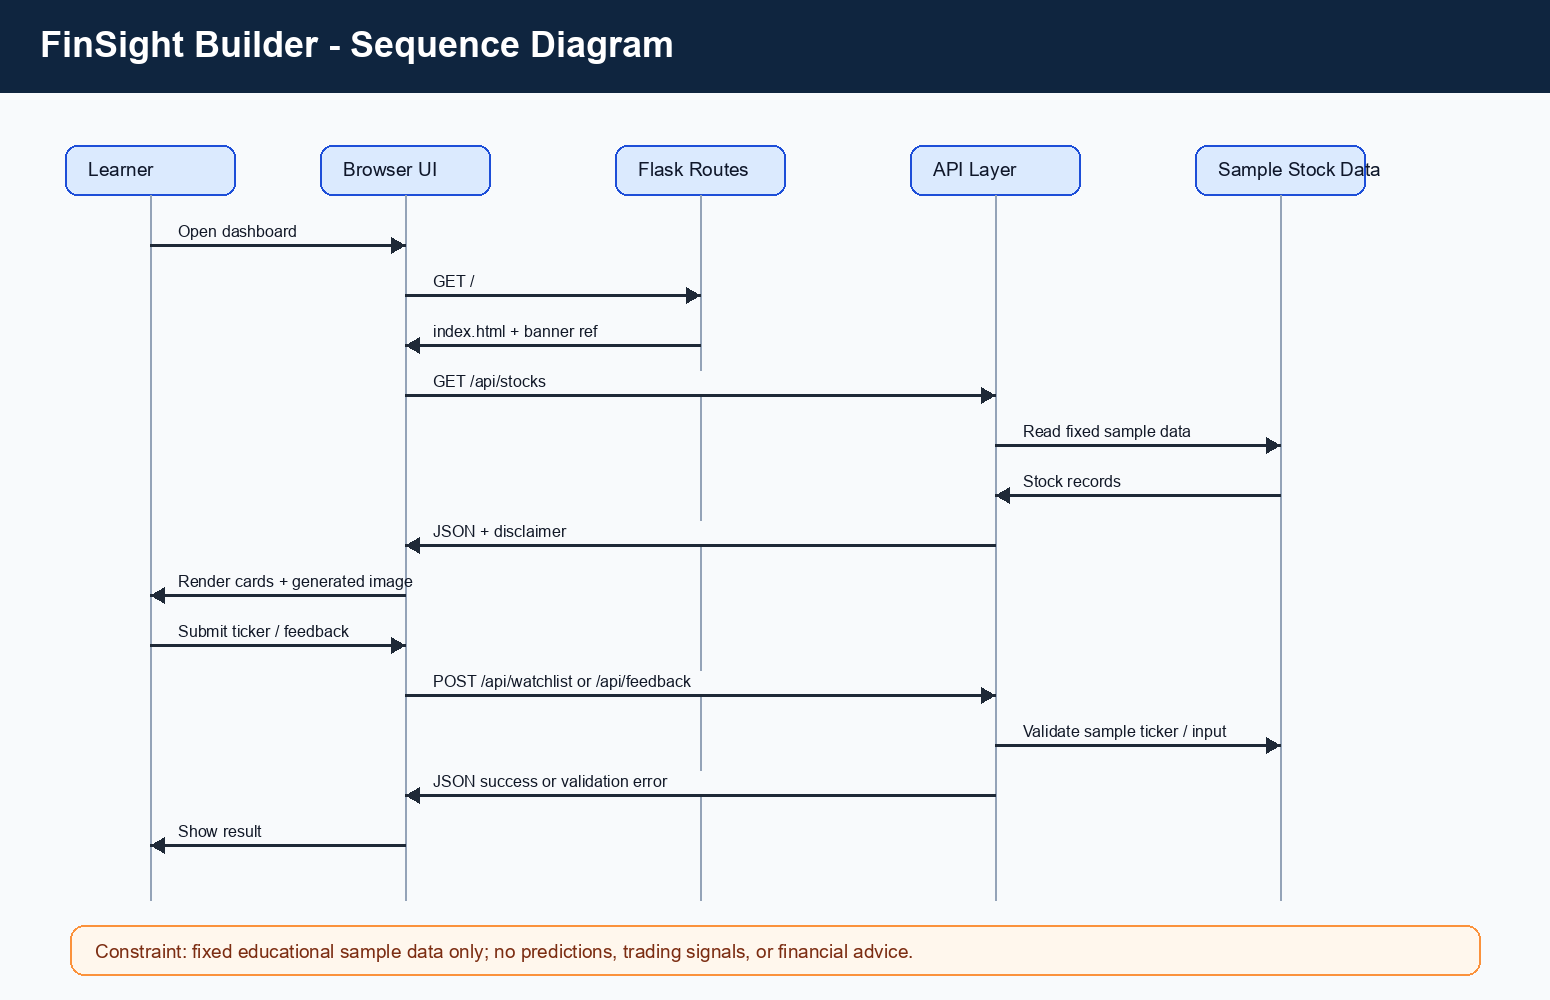

{'artifact': 'sequence_diagram',
 'source_type': 'professional deterministic fallback renderer',
 'output_path': 'Task1\\artifacts\\diagrams\\sequence_diagram.png',
 'validation_checks': ['PlantUML source saved',
  'PNG output exists',
  'render method recorded'],
 'next_stage_use': 'Supports Software evidence, report explanation, and presentation aid',
 'software_marking_criteria': ['automatic UML generation']}

In [122]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import Image as DisplayImage, display

render_status = {}

def fonts():
    def lf(size, bold=False):
        candidates = ["arialbd.ttf" if bold else "arial.ttf", "segoeuib.ttf" if bold else "segoeui.ttf"]
        for name in candidates:
            try:
                return ImageFont.truetype(name, size)
            except OSError:
                pass
        return ImageFont.load_default()
    return lf(36, True), lf(25, True), lf(19), lf(16)

def text_center(d, center, lines, font, fill="#0f172a", gap=5):
    cx, cy = center
    heights = []
    widths = []
    for line in lines:
        box = d.textbbox((0, 0), line, font=font)
        widths.append(box[2]-box[0])
        heights.append(box[3]-box[1])
    total = sum(heights) + gap * (len(lines)-1)
    y = cy - total / 2
    for line, width, height in zip(lines, widths, heights):
        d.text((cx - width/2, y), line, fill=fill, font=font)
        y += height + gap

def draw_actor(d, cx, cy, label, font):
    d.ellipse((cx-20, cy-58, cx+20, cy-18), outline="#0f172a", width=3, fill="#ffffff")
    d.line((cx, cy-18, cx, cy+52), fill="#0f172a", width=3)
    d.line((cx-38, cy+8, cx+38, cy+8), fill="#0f172a", width=3)
    d.line((cx, cy+52, cx-32, cy+98), fill="#0f172a", width=3)
    d.line((cx, cy+52, cx+32, cy+98), fill="#0f172a", width=3)
    text_center(d, (cx, cy+132), label.split("\n"), font)

def polyline(d, points, color="#334155"):
    d.line(points, fill=color, width=3, joint="curve")

def usecase(d, cx, cy, text, font, fill="#ffffff"):
    d.ellipse((cx-145, cy-55, cx+145, cy+55), fill=fill, outline="#2563eb", width=3)
    text_center(d, (cx, cy), text.split("\n"), font)

def professional_use_case_png(path):
    title_font, label_font, small_font, tiny_font = fonts()
    img = Image.new("RGB", (1700, 1050), "#f8fafc")
    d = ImageDraw.Draw(img)
    d.rectangle((0, 0, 1700, 96), fill="#0f253f")
    d.text((44, 25), "FinSight Builder - Use Case Diagram", fill="white", font=title_font)
    d.text((44, 68), "Actors remain outside the system boundary; use cases are grouped by generation, learner interaction, and assessment evidence.", fill="#c9d8ea", font=tiny_font)

    bx1, by1, bx2, by2 = 330, 145, 1320, 900
    d.rounded_rectangle((bx1, by1, bx2, by2), radius=26, outline="#1e3a8a", width=4, fill="#eef6ff")
    d.text((bx1+26, by1+18), "FinSight Builder", fill="#1e3a8a", font=label_font)

    # group labels
    d.rounded_rectangle((380, 220, 760, 560), radius=18, outline="#bfdbfe", width=2, fill="#f8fbff")
    d.text((405, 238), "Generation workflow", fill="#1d4ed8", font=tiny_font)
    d.rounded_rectangle((430, 590, 850, 820), radius=18, outline="#bbf7d0", width=2, fill="#fbfffd")
    d.text((455, 608), "Learner interaction", fill="#15803d", font=tiny_font)
    d.rounded_rectangle((880, 555, 1255, 825), radius=18, outline="#ddd6fe", width=2, fill="#fdfcff")
    d.text((905, 573), "Assessment evidence", fill="#6d28d9", font=tiny_font)

    pos = {
        "Generate SDLC\ndocumentation": (560, 310),
        "Generate UML\ndiagrams": (560, 445),
        "Generate Flask API\nand website": (970, 360),
        "Display generated\nimage": (970, 500),
        "View educational\nrisk briefings": (620, 690),
        "Add ticker to\nwatchlist": (620, 800),
        "Submit\nfeedback": (1020, 700),
        "Run tests and\ndeployment evidence": (1065, 815),
        "Review generated\nartifacts": (1130, 625),
    }
    for text, (cx, cy) in pos.items():
        usecase(d, cx, cy, text, small_font)

    actors = {
        "Student\nDeveloper": (155, 340),
        "Learner\nUser": (155, 735),
        "Coursework\nMarker": (1530, 660),
    }
    for label, (cx, cy) in actors.items():
        draw_actor(d, cx, cy, label, small_font)

    # routed associations reduce crossing lines.
    polyline(d, [(238,340), (330,340), (415,310)])
    polyline(d, [(238,340), (330,340), (415,445)])
    polyline(d, [(238,340), (330,340), (830,360)])
    polyline(d, [(238,340), (330,340), (830,500)])
    polyline(d, [(238,735), (330,735), (475,690)])
    polyline(d, [(238,735), (330,735), (475,800)])
    polyline(d, [(238,735), (330,735), (880,700)])
    polyline(d, [(1447,660), (1320,660), (1275,625)])
    polyline(d, [(1447,660), (1320,660), (1215,815)])

    d.rounded_rectangle((70, 945, 1630, 1010), radius=16, fill="#fff7ed", outline="#fb923c", width=2)
    d.text((98, 966), "Boundary: educational sample data only; no prediction, trading advice, buy/sell recommendation, or investment recommendation.", fill="#7c2d12", font=small_font)
    img.save(path)

# Keep the sequence diagram renderer stable; it is already adequate for the current evidence scope.
def arrow(d, x1, y1, x2, y2, label, font, color="#1f2937"):
    d.line((x1, y1, x2, y2), fill=color, width=3)
    if x2 >= x1:
        d.polygon([(x2, y2), (x2-14, y2-8), (x2-14, y2+8)], fill=color)
    else:
        d.polygon([(x2, y2), (x2+14, y2-8), (x2+14, y2+8)], fill=color)
    d.rectangle((min(x1,x2)+18, y1-24, max(x1,x2)-18, y1-2), fill="#f8fafc")
    d.text((min(x1,x2)+28, y1-23), label, fill="#111827", font=font)

def professional_sequence_png(path):
    title_font, label_font, small_font, tiny_font = fonts()
    img = Image.new("RGB", (1550, 1000), "#f8fafc")
    d = ImageDraw.Draw(img)
    d.rectangle((0, 0, 1550, 92), fill="#0f253f")
    d.text((40, 24), "FinSight Builder - Sequence Diagram", fill="white", font=title_font)
    participants = [(150,"Learner"),(405,"Browser UI"),(700,"Flask Routes"),(995,"API Layer"),(1280,"Sample Stock Data")]
    for x, name in participants:
        d.rounded_rectangle((x-85, 145, x+85, 195), radius=12, fill="#dbeafe", outline="#1d4ed8", width=2)
        d.text((x-62, 158), name, fill="#0f172a", font=small_font)
        d.line((x, 195, x, 900), fill="#94a3b8", width=2)
    steps = [
        (150,405,"Open dashboard"), (405,700,"GET /"), (700,405,"index.html + banner ref"),
        (405,995,"GET /api/stocks"), (995,1280,"Read fixed sample data"), (1280,995,"Stock records"),
        (995,405,"JSON + disclaimer"), (405,150,"Render cards + generated image"),
        (150,405,"Submit ticker / feedback"), (405,995,"POST /api/watchlist or /api/feedback"),
        (995,1280,"Validate sample ticker / input"), (995,405,"JSON success or validation error"), (405,150,"Show result"),
    ]
    y = 245
    for x1, x2, label in steps:
        arrow(d, x1, y, x2, y, label, tiny_font)
        y += 50
    d.rounded_rectangle((70, 925, 1480, 975), radius=14, fill="#fff7ed", outline="#fb923c", width=2)
    d.text((95, 940), "Constraint: fixed educational sample data only; no predictions, trading signals, or financial advice.", fill="#7c2d12", font=small_font)
    img.save(path)

def render_diagram(name, puml_source, fallback_func):
    puml_path = DIAGRAM_DIR / f"{name}.puml"
    png_path = DIAGRAM_DIR / f"{name}.png"
    puml_path.write_text(puml_source.strip() + "\n", encoding="utf-8")
    if png_path.exists():
        png_path.unlink()
    attempts = []
    final_method = None
    fallback_used = False
    fallback_reason = ""

    if shutil.which("plantuml"):
        attempts.append({"method": "local PlantUML", "status": "attempted"})
        try:
            subprocess.run(["plantuml", "-tpng", str(puml_path)], check=True, capture_output=True, text=True, timeout=30)
            if png_path.exists() and png_path.stat().st_size > 0:
                attempts[-1]["status"] = "success"
                final_method = "local PlantUML"
        except Exception:
            attempts[-1]["status"] = "unavailable"
    else:
        attempts.append({"method": "local PlantUML", "status": "unavailable"})

    attempts.append({"method": "course helper", "status": "not run", "reason": "disabled in this local run to avoid duplicate artifact-directory output"})

    if not final_method:
        fallback_func(png_path)
        final_method = "professional deterministic fallback renderer"
        fallback_used = True
        fallback_reason = "PlantUML renderer unavailable in this local environment"

    render_status[name] = {
        "diagram_name": name,
        "puml_source_path": str(puml_path.relative_to(REPO_ROOT)),
        "png_output_path": str(png_path.relative_to(REPO_ROOT)),
        "render_methods_attempted": attempts,
        "final_render_method": final_method,
        "fallback_used": fallback_used,
        "fallback_reason": fallback_reason,
    }
    print(f"{name}: {final_method}; saved {png_path.relative_to(REPO_ROOT)}")
    return puml_path, png_path

use_case_puml = """
@startuml
left to right direction
skinparam linetype ortho
skinparam packageStyle rectangle
skinparam actorStyle awesome
title FinSight Builder Use Case Diagram
actor "Student Developer" as Developer
actor "Learner User" as Learner
actor "Coursework Marker" as Marker
rectangle "FinSight Builder" {
  package "Generation workflow" {
    usecase "Generate SDLC\ndocumentation" as UC1
    usecase "Generate UML\ndiagrams" as UC2
    usecase "Generate Flask API\nand website" as UC3
    usecase "Display generated\nimage" as UC4
  }
  package "Learner interaction" {
    usecase "View educational\nrisk briefings" as UC5
    usecase "Add ticker to\nwatchlist" as UC6
    usecase "Submit\nfeedback" as UC7
  }
  package "Assessment evidence" {
    usecase "Run tests and\ndeployment evidence" as UC8
    usecase "Review generated\nartifacts" as UC9
  }
}
Developer --> UC1
Developer --> UC2
Developer --> UC3
Developer --> UC4
Learner --> UC5
Learner --> UC6
Learner --> UC7
Marker --> UC8
Marker --> UC9
@enduml
"""

sequence_puml = """
@startuml
title FinSight Builder Dashboard and API Sequence
autonumber
actor "Learner User" as User
participant "Browser UI" as Browser
participant "Flask Routes" as Flask
participant "API Layer" as API
database "Sample Stock Data" as Data
User -> Browser: Open dashboard
Browser -> Flask: GET /
Flask --> Browser: index.html with generated image reference
Browser -> API: GET /api/stocks
API -> Data: Read fixed sample stock data
Data --> API: Stock records
API --> Browser: JSON stock list + disclaimer
Browser --> User: Render stock cards and generated banner
User -> Browser: Submit watchlist ticker or feedback
Browser -> API: POST /api/watchlist or /api/feedback
API -> Data: Validate ticker or input fields
API --> Browser: JSON success or validation error
Browser --> User: Show result
note over API,Data: Educational sample data only; no prediction or financial advice.
@enduml
"""

uc_puml, uc_png = render_diagram("use_case_diagram", use_case_puml, professional_use_case_png)
seq_puml, seq_png = render_diagram("sequence_diagram", sequence_puml, professional_sequence_png)
status_path = DIAGRAM_DIR / "render_status.json"
status_path.write_text(json.dumps(render_status, indent=2), encoding="utf-8")
print("Render status saved:", status_path.relative_to(REPO_ROOT))
display(DisplayImage(filename=str(uc_png)))
display(DisplayImage(filename=str(seq_png)))
record_generation("use_case_diagram", render_status["use_case_diagram"]["final_render_method"], ["PlantUML source saved", "PNG output exists", "render method recorded"], uc_png, "Supports Software evidence, report explanation, and presentation aid", ["automatic UML generation"])
record_generation("sequence_diagram", render_status["sequence_diagram"]["final_render_method"], ["PlantUML source saved", "PNG output exists", "render method recorded"], seq_png, "Supports Software evidence, report explanation, and presentation aid", ["automatic UML generation"])


## 2.2 AI generated - Flask API and website code

The implementation below is the stabilised generated code derived from the PRD, user stories, and API specification. The notebook keeps a deterministic version because this part must pass tests consistently, but the surrounding prompt chain shows how the requirements drive the generated API and website surface. The endpoints are intentionally educational and do not include prediction, recommendation, or financial-advice functions.


In [123]:
main_py = 'from flask import Flask, jsonify, request, send_from_directory\n\n\napp = Flask(__name__, static_folder="static")\n\nDISCLAIMER = "For educational demonstration only. Not financial advice."\n\nSTOCKS = [\n    {\n        "ticker": "AAPL",\n        "name": "Apple Inc.",\n        "sector": "Technology hardware",\n        "mock_price": 184.35,\n        "risk_level": "medium",\n        "briefing": "Revenue depends on device cycles, services growth, supply chain resilience, and consumer demand.",\n    },\n    {\n        "ticker": "MSFT",\n        "name": "Microsoft Corporation",\n        "sector": "Cloud and productivity software",\n        "mock_price": 421.16,\n        "risk_level": "low",\n        "briefing": "Diversified software and cloud revenue may reduce volatility, but AI infrastructure costs remain material.",\n    },\n    {\n        "ticker": "NVDA",\n        "name": "NVIDIA Corporation",\n        "sector": "Semiconductors",\n        "mock_price": 912.44,\n        "risk_level": "high",\n        "briefing": "AI chip demand is strong, while valuation, export controls, and supply constraints increase uncertainty.",\n    },\n    {\n        "ticker": "TSLA",\n        "name": "Tesla, Inc.",\n        "sector": "Electric vehicles",\n        "mock_price": 177.53,\n        "risk_level": "high",\n        "briefing": "Margins, delivery growth, battery costs, regulation, and leadership attention can affect sentiment.",\n    },\n]\n\nwatchlist = []\nfeedback_items = []\n\n\ndef find_stock(ticker):\n    normalized = str(ticker or "").strip().upper()\n    return next((stock for stock in STOCKS if stock["ticker"] == normalized), None)\n\n\n@app.get("/health")\ndef health():\n    return jsonify(status="ok", service="FinSight Builder", disclaimer=DISCLAIMER)\n\n\n@app.get("/api/stocks")\ndef list_stocks():\n    return jsonify(stocks=STOCKS, count=len(STOCKS), disclaimer=DISCLAIMER)\n\n\n@app.get("/api/stocks/<ticker>")\ndef stock_detail(ticker):\n    stock = find_stock(ticker)\n    if stock is None:\n        return jsonify(error="stock_not_found", disclaimer=DISCLAIMER), 404\n    return jsonify(stock=stock, disclaimer=DISCLAIMER)\n\n\n@app.post("/api/watchlist")\ndef add_watchlist_item():\n    payload = request.get_json(silent=True) or {}\n    ticker = str(payload.get("ticker", "")).strip().upper()\n    stock = find_stock(ticker)\n    if not ticker:\n        return jsonify(error="ticker is required"), 400\n    if stock is None:\n        return jsonify(error="ticker is not in the educational sample dataset"), 404\n    if ticker not in watchlist:\n        watchlist.append(ticker)\n    return jsonify(message="ticker added", watchlist=watchlist, stock=stock, disclaimer=DISCLAIMER), 201\n\n\n@app.get("/api/watchlist")\ndef get_watchlist():\n    items = [stock for stock in STOCKS if stock["ticker"] in watchlist]\n    return jsonify(watchlist=items, tickers=watchlist, disclaimer=DISCLAIMER)\n\n\n@app.post("/api/feedback")\ndef submit_feedback():\n    payload = request.get_json(silent=True) or {}\n    name = str(payload.get("name", "")).strip()\n    message = str(payload.get("message", "")).strip()\n    rating = payload.get("rating")\n    if not name or not message or rating is None:\n        return jsonify(error="name, message, and rating are required"), 400\n    try:\n        rating = int(rating)\n    except (TypeError, ValueError):\n        return jsonify(error="rating must be an integer"), 400\n    if rating < 1 or rating > 5:\n        return jsonify(error="rating must be between 1 and 5"), 400\n    item = {"id": len(feedback_items) + 1, "name": name, "message": message, "rating": rating}\n    feedback_items.append(item)\n    return jsonify(message="feedback submitted", feedback=item), 201\n\n\n@app.get("/api/feedback")\ndef list_feedback():\n    return jsonify(items=feedback_items, count=len(feedback_items))\n\n\n@app.get("/api/risk-summary")\ndef risk_summary():\n    counts = {"low": 0, "medium": 0, "high": 0}\n    for stock in STOCKS:\n        counts[stock["risk_level"]] += 1\n    return jsonify(risk_summary=counts, disclaimer=DISCLAIMER)\n\n\n@app.get("/")\ndef index():\n    return send_from_directory(".", "index.html")\n\n\n@app.get("/<path:filename>")\ndef serve_static_file(filename):\n    return send_from_directory(".", filename)\n\n\nif __name__ == "__main__":\n    app.run(host="0.0.0.0", port=5005, debug=False)\n'
index_html = r'''<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1" />
  <title>FinSight Builder</title>
  <style>
    :root {
      --bg: #eef3f8;
      --panel: #ffffff;
      --ink: #172033;
      --muted: #64748b;
      --line: #d7e0ea;
      --navy: #102033;
      --green: #166534;
      --amber: #b45309;
      --red: #b91c1c;
      --blue: #2563eb;
    }
    * { box-sizing: border-box; }
    body { margin: 0; font-family: Inter, Segoe UI, Arial, sans-serif; background: var(--bg); color: var(--ink); line-height: 1.55; }
    .hero { background: linear-gradient(135deg, #102033 0%, #1d3b5c 55%, #0f766e 100%); color: #fff; padding: 34px 0 24px; }
    .wrap { width: min(1180px, calc(100% - 32px)); margin: 0 auto; }
    .hero-grid { display: grid; grid-template-columns: 1.05fr 0.95fr; gap: 28px; align-items: center; }
    .eyebrow { color: #a7f3d0; font-weight: 700; letter-spacing: .04em; text-transform: uppercase; font-size: .82rem; }
    h1 { margin: 8px 0 10px; font-size: clamp(2.3rem, 5vw, 4.4rem); line-height: 1.02; }
    h2 { margin: 0 0 14px; font-size: 1.18rem; }
    h3 { margin: 0; font-size: 1rem; }
    .subtitle { max-width: 680px; color: #d7e6f5; margin: 0; font-size: 1.04rem; }
    .hero-metrics { display: grid; grid-template-columns: repeat(3, 1fr); gap: 10px; margin-top: 22px; }
    .metric { border: 1px solid rgba(255,255,255,.22); border-radius: 12px; padding: 13px; background: rgba(255,255,255,.08); }
    .metric strong { display: block; font-size: 1.45rem; }
    .banner-frame { border-radius: 18px; overflow: hidden; border: 1px solid rgba(255,255,255,.25); box-shadow: 0 24px 60px rgba(0,0,0,.28); background: #0b1626; }
    .banner { width: 100%; display: block; aspect-ratio: 16 / 7; object-fit: cover; }
    .notice { margin: 18px 0 0; padding: 12px 14px; border: 1px solid rgba(251,191,36,.55); background: rgba(255,247,237,.12); color: #fff7ed; border-radius: 12px; }
    main { padding: 26px 0 42px; }
    .layout { display: grid; grid-template-columns: minmax(0, 1.75fr) minmax(330px, .9fr); gap: 18px; align-items: start; }
    .panel { background: var(--panel); border: 1px solid var(--line); border-radius: 12px; padding: 18px; box-shadow: 0 10px 28px rgba(15, 35, 63, .06); }
    .cards { display: grid; grid-template-columns: repeat(auto-fit, minmax(235px, 1fr)); gap: 14px; }
    .stock { border: 1px solid var(--line); border-radius: 12px; padding: 15px; background: linear-gradient(180deg, #fff 0%, #f8fafc 100%); }
    .stock-top { display: flex; justify-content: space-between; gap: 10px; align-items: start; }
    .ticker { font-size: 1.45rem; font-weight: 800; }
    .muted { color: var(--muted); }
    .price { font-weight: 800; margin-top: 8px; font-size: 1.1rem; }
    .badge { display: inline-block; border-radius: 999px; padding: 4px 10px; font-size: .74rem; font-weight: 800; text-transform: uppercase; white-space: nowrap; }
    .low { background: #dcfce7; color: var(--green); }
    .medium { background: #fef3c7; color: var(--amber); }
    .high { background: #fee2e2; color: var(--red); }
    .side-stack { display: grid; gap: 18px; }
    .summary { display: grid; grid-template-columns: repeat(3, 1fr); gap: 9px; margin-bottom: 14px; }
    .summary div { border: 1px solid var(--line); border-radius: 12px; padding: 12px 8px; text-align: center; background: #f8fafc; }
    .summary strong { display: block; font-size: 1.65rem; }
    form { display: grid; gap: 10px; }
    label { font-weight: 750; font-size: .88rem; }
    input, textarea, button { width: 100%; border-radius: 10px; border: 1px solid var(--line); padding: 10px 12px; font: inherit; }
    button { border: 0; background: #1f6f50; color: white; font-weight: 800; cursor: pointer; }
    button.secondary { background: #334155; }
    .status { min-height: 24px; color: var(--muted); font-size: .92rem; }
    .api-list { display: grid; gap: 8px; }
    .api-list code { display: block; padding: 8px 10px; border-radius: 9px; background: #eff6ff; color: #1d4ed8; border: 1px solid #bfdbfe; }
    @media (max-width: 900px) { .hero-grid, .layout { grid-template-columns: 1fr; } .hero-metrics { grid-template-columns: 1fr; } }
  </style>
</head>
<body>
  <section class="hero">
    <div class="wrap hero-grid">
      <div>
        <div class="eyebrow">AI-powered software engineering evidence</div>
        <h1>FinSight Builder</h1>
        <p class="subtitle">A generated Flask API and educational dashboard for sample stock watchlists, risk briefings, tests, Docker deployment, and CI evidence.</p>
        <div class="hero-metrics">
          <div class="metric"><strong id="stockCount">0</strong><span>sample stocks</span></div>
          <div class="metric"><strong>9</strong><span>pytest checks</span></div>
          <div class="metric"><strong>0</strong><span>advice features</span></div>
        </div>
        <div class="notice">For educational demonstration only. Not financial advice. Prices are fixed mock values.</div>
      </div>
      <div class="banner-frame"><img class="banner" src="static/generated_market_banner.png" alt="Automatically generated FinSight Builder market education banner" /></div>
    </div>
  </section>

  <main class="wrap">
    <div class="layout">
      <section class="panel">
        <h2>Sample Stock Educational Briefings</h2>
        <div id="stockCards" class="cards"></div>
      </section>

      <aside class="side-stack">
        <section class="panel">
          <h2>Risk Summary</h2>
          <div class="summary">
            <div><strong id="lowCount">0</strong><span class="muted">Low</span></div>
            <div><strong id="mediumCount">0</strong><span class="muted">Medium</span></div>
            <div><strong id="highCount">0</strong><span class="muted">High</span></div>
          </div>
        </section>

        <section class="panel">
          <h2>API Evidence</h2>
          <div class="api-list">
            <code>GET /api/stocks</code><code>GET /api/risk-summary</code><code>POST /api/watchlist</code><code>POST /api/feedback</code>
          </div>
        </section>

        <section class="panel">
          <h2>Add Watchlist Ticker</h2>
          <form id="watchlistForm">
            <label for="ticker">Ticker</label>
            <input id="ticker" name="ticker" placeholder="AAPL" maxlength="8" required />
            <button type="submit">Add ticker</button>
            <div id="watchlistStatus" class="status"></div>
          </form>
        </section>

        <section class="panel">
          <h2>Feedback</h2>
          <form id="feedbackForm">
            <label for="name">Name</label><input id="name" name="name" required />
            <label for="rating">Rating 1-5</label><input id="rating" name="rating" type="number" min="1" max="5" required />
            <label for="message">Message</label><textarea id="message" name="message" rows="3" required></textarea>
            <button class="secondary" type="submit">Submit feedback</button>
            <div id="feedbackStatus" class="status"></div>
          </form>
        </section>
      </aside>
    </div>
  </main>

  <script>
    const stockCards = document.getElementById("stockCards");
    const watchlistStatus = document.getElementById("watchlistStatus");
    const feedbackStatus = document.getElementById("feedbackStatus");
    function escapeHtml(value) { return String(value ?? "").replace(/&/g,"&amp;").replace(/</g,"&lt;").replace(/>/g,"&gt;").replace(/"/g,"&quot;").replace(/'/g,"&#039;"); }
    async function loadStocks() {
      const [stocksResponse, riskResponse] = await Promise.all([fetch("/api/stocks"), fetch("/api/risk-summary")]);
      const stocksData = await stocksResponse.json(); const riskData = await riskResponse.json();
      document.getElementById("stockCount").textContent = stocksData.count;
      stockCards.innerHTML = stocksData.stocks.map((stock) => `
        <article class="stock"><div class="stock-top"><div><div class="ticker">${escapeHtml(stock.ticker)}</div><h3>${escapeHtml(stock.name)}</h3></div><span class="badge ${escapeHtml(stock.risk_level)}">${escapeHtml(stock.risk_level)}</span></div><div class="muted">${escapeHtml(stock.sector)}</div><div class="price">$${Number(stock.mock_price).toFixed(2)}</div><p>${escapeHtml(stock.briefing)}</p></article>`).join("");
      document.getElementById("lowCount").textContent = riskData.risk_summary.low;
      document.getElementById("mediumCount").textContent = riskData.risk_summary.medium;
      document.getElementById("highCount").textContent = riskData.risk_summary.high;
    }
    document.getElementById("watchlistForm").addEventListener("submit", async (event) => { event.preventDefault(); const ticker = document.getElementById("ticker").value.trim(); const response = await fetch("/api/watchlist", { method: "POST", headers: { "Content-Type": "application/json" }, body: JSON.stringify({ ticker }) }); const data = await response.json(); watchlistStatus.textContent = response.ok ? `Watchlist: ${data.watchlist.join(", ")}` : data.error; });
    document.getElementById("feedbackForm").addEventListener("submit", async (event) => { event.preventDefault(); const payload = { name: document.getElementById("name").value.trim(), rating: document.getElementById("rating").value, message: document.getElementById("message").value.trim() }; const response = await fetch("/api/feedback", { method: "POST", headers: { "Content-Type": "application/json" }, body: JSON.stringify(payload) }); const data = await response.json(); feedbackStatus.textContent = response.ok ? "Feedback submitted." : data.error; if (response.ok) event.target.reset(); });
    loadStocks().catch(() => { stockCards.innerHTML = "<p>Unable to load stock data. Start the Flask API and refresh.</p>"; });
  </script>
</body>
</html>
'''
requirements_txt = 'Flask==3.0.3\n'

(FLASK_DIR / "main.py").write_text(main_py, encoding="utf-8")
(FLASK_DIR / "index.html").write_text(index_html, encoding="utf-8")
(FLASK_DIR / "requirements.txt").write_text(requirements_txt, encoding="utf-8")

print("Generated Flask app files:")
for path in [FLASK_DIR / "main.py", FLASK_DIR / "index.html", FLASK_DIR / "requirements.txt"]:
    print("-", path.relative_to(REPO_ROOT))

Generated Flask app files:
- Task1\artifacts\app\flask\main.py
- Task1\artifacts\app\flask\index.html
- Task1\artifacts\app\flask\requirements.txt


## 2.3 AI generated - Website image

The website requires a generated visual asset. This notebook keeps an automatically generated local fallback image (`generated_market_banner.png`) so the project remains reproducible without an image API. If an image-generation API key is available, the same prompt could be sent to an image model, but the coursework does not depend on external image credits.


In [124]:
from PIL import Image, ImageDraw, ImageFont

out = STATIC_DIR / "generated_market_banner.png"
w, h = 1600, 700
img = Image.new("RGB", (w, h), "#0f253f")
d = ImageDraw.Draw(img)
# layered background
for y in range(h):
    r = int(15 + 12 * y / h)
    g = int(37 + 55 * y / h)
    b = int(63 + 45 * y / h)
    d.line((0, y, w, y), fill=(r, g, b))
# grid
for x in range(80, w, 120): d.line((x, 120, x, h-80), fill=(42, 76, 105), width=1)
for y in range(160, h-80, 90): d.line((70, y, w-80, y), fill=(42, 76, 105), width=1)
# chart cards
card = (860, 135, 1490, 560)
d.rounded_rectangle(card, radius=28, fill=(248, 250, 252), outline=(190, 215, 230), width=3)
points = [(910, 475), (1000, 410), (1090, 438), (1185, 330), (1275, 365), (1370, 255), (1450, 290)]
d.line(points, fill="#16a34a", width=9)
for pnt in points: d.ellipse((pnt[0]-8, pnt[1]-8, pnt[0]+8, pnt[1]+8), fill="#166534")
# risk chips
chips = [(920,170,"LOW", "#dcfce7", "#166534"), (1070,170,"MEDIUM", "#fef3c7", "#b45309"), (1260,170,"HIGH", "#fee2e2", "#b91c1c")]
try:
    title_font = ImageFont.truetype("arial.ttf", 76)
    sub_font = ImageFont.truetype("arial.ttf", 32)
    chip_font = ImageFont.truetype("arial.ttf", 24)
    small_font = ImageFont.truetype("arial.ttf", 22)
except OSError:
    title_font = sub_font = chip_font = small_font = ImageFont.load_default()
for x,y,text,bg,fg in chips:
    d.rounded_rectangle((x,y,x+120,y+46), radius=18, fill=bg)
    d.text((x+22,y+10), text, fill=fg, font=chip_font)
d.text((88, 120), "FinSight Builder", fill="white", font=title_font)
d.text((94, 215), "AI-generated educational stock watchlist", fill="#cfe4f7", font=sub_font)
d.text((94, 265), "Risk briefing dashboard + Flask API evidence", fill="#cfe4f7", font=sub_font)
d.rounded_rectangle((95, 430, 520, 500), radius=22, fill="#ffffff")
d.text((125, 450), "Not financial advice", fill="#0f253f", font=sub_font)
d.text((92, 585), "Fixed sample data | No predictions | No trading recommendations", fill="#a7f3d0", font=small_font)
img.save(out)
print("Generated image written:", out.relative_to(REPO_ROOT), "size:", out.stat().st_size)
record_generation("generated_image", "automatic programmatic image generation", ["PNG file exists", "Referenced by index.html", "Contains not-financial-advice message"], out, "Supports website generated-image marking criterion and Task2 deployment screenshot", ["website with generated image"])


Generated image written: Task1\artifacts\app\flask\static\generated_market_banner.png size: 51846


{'artifact': 'generated_image',
 'source_type': 'automatic programmatic image generation',
 'output_path': 'Task1\\artifacts\\app\\flask\\static\\generated_market_banner.png',
 'validation_checks': ['PNG file exists',
  'Referenced by index.html',
  'Contains not-financial-advice message'],
 'next_stage_use': 'Supports website generated-image marking criterion and Task2 deployment screenshot',
 'software_marking_criteria': ['website with generated image']}

## 2.4 AI generated - Tests

In [125]:
test_app_py = 'import sys\nfrom pathlib import Path\n\nAPP_DIR = Path(__file__).resolve().parents[1] / "flask"\nsys.path.insert(0, str(APP_DIR))\n\nfrom main import app, feedback_items, watchlist  # noqa: E402\n\n\ndef client():\n    app.config.update(TESTING=True)\n    watchlist.clear()\n    feedback_items.clear()\n    return app.test_client()\n\n\ndef test_health_endpoint():\n    response = client().get("/health")\n    assert response.status_code == 200\n    assert response.get_json()["status"] == "ok"\n\n\ndef test_stocks_have_required_fields():\n    response = client().get("/api/stocks")\n    data = response.get_json()\n    assert response.status_code == 200\n    assert data["count"] >= 3\n    for stock in data["stocks"]:\n        assert {"ticker", "name", "mock_price", "risk_level", "briefing"} <= stock.keys()\n\n\ndef test_stock_detail_and_unknown_ticker():\n    ok_response = client().get("/api/stocks/AAPL")\n    missing_response = client().get("/api/stocks/UNKNOWN")\n    assert ok_response.status_code == 200\n    assert ok_response.get_json()["stock"]["ticker"] == "AAPL"\n    assert missing_response.status_code == 404\n\n\ndef test_watchlist_validation_and_success():\n    test_client = client()\n    missing = test_client.post("/api/watchlist", json={})\n    created = test_client.post("/api/watchlist", json={"ticker": "msft"})\n    assert missing.status_code == 400\n    assert created.status_code == 201\n    assert "MSFT" in created.get_json()["watchlist"]\n\n\ndef test_feedback_validation_and_success():\n    test_client = client()\n    invalid = test_client.post("/api/feedback", json={"name": "Feiyu"})\n    valid = test_client.post(\n        "/api/feedback",\n        json={"name": "Feiyu", "message": "Clear dashboard", "rating": 5},\n    )\n    assert invalid.status_code == 400\n    assert valid.status_code == 201\n    assert valid.get_json()["feedback"]["rating"] == 5\n\n\ndef test_risk_summary_shape():\n    response = client().get("/api/risk-summary")\n    assert response.status_code == 200\n    assert set(response.get_json()["risk_summary"]) == {"low", "medium", "high"}\n\n\ndef test_index_page_and_generated_image_reference():\n    response = client().get("/")\n    assert response.status_code == 200\n    html = response.get_data(as_text=True)\n    assert "generated_market_banner.png" in html\n    assert "API Evidence" in html\n\n\ndef test_generated_image_file_exists():\n    image_path = APP_DIR / "static" / "generated_market_banner.png"\n    assert image_path.exists()\n    assert image_path.stat().st_size > 0\n\n\ndef test_feedback_get_returns_submitted_items():\n    test_client = client()\n    created = test_client.post(\n        "/api/feedback",\n        json={"name": "Feiyu", "message": "Useful risk summary", "rating": 4},\n    )\n    response = test_client.get("/api/feedback")\n    assert created.status_code == 201\n    assert response.status_code == 200\n    data = response.get_json()\n    assert data["count"] == 1\n    assert data["items"][0]["message"] == "Useful risk summary"\n'
(TEST_DIR / "test_app.py").write_text(test_app_py, encoding="utf-8")
print("Tests written:", TEST_DIR / "test_app.py")
print("Test coverage: 9 tests covering health, stocks, detail/404, watchlist validation, feedback validation/retrieval, risk summary, index page, and generated image.")
record_generation("pytest_tests", "generated from user stories and API spec, then stabilised", ["Covers success paths", "Covers validation/error paths", "Checks website/image and feedback retrieval"], TEST_DIR / "test_app.py", "Verifies Flask implementation locally and in CI", ["testing practices", "CI/CD workflow evidence"])


Tests written: C:\Users\31075\Desktop\大二下\dts114\CW\2472811-Feiyu_Chen\Task1\artifacts\app\tests\test_app.py
Test coverage: 9 tests covering health, stocks, detail/404, watchlist validation, feedback validation/retrieval, risk summary, index page, and generated image.


{'artifact': 'pytest_tests',
 'source_type': 'generated from user stories and API spec, then stabilised',
 'output_path': 'Task1\\artifacts\\app\\tests\\test_app.py',
 'validation_checks': ['Covers success paths',
  'Covers validation/error paths',
  'Checks website/image and feedback retrieval'],
 'next_stage_use': 'Verifies Flask implementation locally and in CI',
 'software_marking_criteria': ['testing practices', 'CI/CD workflow evidence']}

# Phase 3: Operation

The Operation phase prepares the system for testing, deployment, and workflow automation. This notebook writes Docker and CI files, then performs lightweight validation checks.

## 3.1 Docker and CI/CD generation

In [126]:
dockerfile = 'FROM python:3.11-slim\n\nWORKDIR /app\n\nCOPY flask/requirements.txt .\nRUN pip install --no-cache-dir -r requirements.txt\n\nCOPY flask/ .\n\nEXPOSE 5005\nENV FLASK_APP=main.py\nENV FLASK_ENV=production\n\nCMD ["python", "main.py"]\n'
docker_compose = 'services:\n  finsight-builder:\n    build:\n      context: .\n      dockerfile: docker/Dockerfile\n    container_name: finsight-builder\n    ports:\n      - "5005:5005"\n    environment:\n      - FLASK_ENV=production\n      - FLASK_APP=main.py\n    restart: unless-stopped\n'
ci_yml = 'name: FinSight Builder CI\n\non:\n  push:\n  pull_request:\n\njobs:\n  test-and-build:\n    runs-on: ubuntu-latest\n    steps:\n      - name: Check out repository\n        uses: actions/checkout@v4\n\n      - name: Set up Python\n        uses: actions/setup-python@v5\n        with:\n          python-version: "3.11"\n\n      - name: Install dependencies\n        run: |\n          python -m pip install --upgrade pip\n          pip install -r Task1/artifacts/app/flask/requirements.txt pytest\n\n      - name: Run pytest\n        run: pytest Task1/artifacts/app/tests\n\n      - name: Build Docker image\n        run: docker build -f Task1/artifacts/app/docker/Dockerfile Task1/artifacts/app\n'

(DOCKER_DIR / "Dockerfile").write_text(dockerfile, encoding="utf-8")
(APP_DIR / "docker-compose.yml").write_text(docker_compose, encoding="utf-8")
(CI_DIR / "ci.yml").write_text(ci_yml, encoding="utf-8")
(APP_CI_DIR / "ci.yml").write_text(ci_yml, encoding="utf-8")

print("Docker/CI artifacts written:")
for path in [DOCKER_DIR / "Dockerfile", APP_DIR / "docker-compose.yml", CI_DIR / "ci.yml", APP_CI_DIR / "ci.yml"]:
    print("-", path.relative_to(REPO_ROOT))

Docker/CI artifacts written:
- Task1\artifacts\app\docker\Dockerfile
- Task1\artifacts\app\docker-compose.yml
- .github\workflows\ci.yml
- Task1\artifacts\app\.github\workflows\ci.yml


## Final Generation Manifest

The manifest is saved after all generation stages so it covers documentation, UML, application code, website, generated image, tests, Docker/CI, and evidence links.


In [127]:
manifest_path = ARTIFACTS / "generation_manifest.json"
manifest_path.write_text(json.dumps(generation_manifest, indent=2), encoding="utf-8")
manifest_rows = ["| Artifact | Source type | Output path | Next-stage use |", "|---|---|---|---|"]
for item in generation_manifest:
    manifest_rows.append(f"| {item['artifact']} | {item['source_type']} | `{item['output_path']}` | {item['next_stage_use']} |")
display(Markdown("\n".join(manifest_rows)))
print("Generation manifest saved:", manifest_path.relative_to(REPO_ROOT))


| Artifact | Source type | Output path | Next-stage use |
|---|---|---|---|
| live_llm_generation_sample | LLM draft rejected; reviewed correction used | `Task1\artifacts\llm_evidence\live_llm_generation_sample.md` | Provides explicit evidence of live LLM integration while preserving reproducible fallback execution |
| problem_statement | reviewed fallback | `Task1\artifacts\problem_statement.md` | Grounds personas and PRD |
| personas | reviewed fallback | `Task1\artifacts\personas.md` | Informs PRD priorities and user stories |
| prd | reviewed fallback | `Task1\artifacts\prd.md` | Drives user stories, API specification, and implementation scope |
| user_stories | reviewed fallback | `Task1\artifacts\user_stories.json` | Maps requirements into API and pytest coverage |
| api_spec | reviewed fallback | `Task1\artifacts\api_spec.md` | Informs Flask routes and API tests |
| use_case_diagram | professional deterministic fallback renderer | `Task1\artifacts\diagrams\use_case_diagram.png` | Supports Software evidence, report explanation, and presentation aid |
| sequence_diagram | professional deterministic fallback renderer | `Task1\artifacts\diagrams\sequence_diagram.png` | Supports Software evidence, report explanation, and presentation aid |
| generated_image | automatic programmatic image generation | `Task1\artifacts\app\flask\static\generated_market_banner.png` | Supports website generated-image marking criterion and Task2 deployment screenshot |
| pytest_tests | generated from user stories and API spec, then stabilised | `Task1\artifacts\app\tests\test_app.py` | Verifies Flask implementation locally and in CI |

Generation manifest saved: Task1\artifacts\generation_manifest.json


## 3.2 Validation commands and Task2 evidence

These commands are intentionally separated from generation so markers can run them safely in the required environment. Task2 evidence should include commit history, deployed website, GitHub Actions success, API JSON, Docker container/log evidence, and pytest output.


In [128]:
validation_commands = {
    "pytest": "python -m pytest Task1/artifacts/app/tests",
    "run_flask": "python Task1/artifacts/app/flask/main.py",
    "docker_compose": "docker compose -f Task1/artifacts/app/docker-compose.yml up --build -d",
    "website": "http://127.0.0.1:5005/",
    "health": "http://127.0.0.1:5005/health",
    "stocks": "http://127.0.0.1:5005/api/stocks",
}
task2_evidence = [
    "Task2/screenshots/01_commit_records.png",
    "Task2/screenshots/02_docker_deployed_website.png",
    "Task2/screenshots/03_github_actions_success.png",
    "Task2/screenshots/04_api_health_or_stocks_optional.png",
    "Task2/screenshots/05_docker_container_optional.png",
    "Task2/test_results/pytest_output.txt",
]
print(json.dumps({"validation_commands": validation_commands, "task2_evidence": task2_evidence}, indent=2))


{
  "validation_commands": {
    "pytest": "python -m pytest Task1/artifacts/app/tests",
    "run_flask": "python Task1/artifacts/app/flask/main.py",
    "docker_compose": "docker compose -f Task1/artifacts/app/docker-compose.yml up --build -d",
    "website": "http://127.0.0.1:5005/",
    "health": "http://127.0.0.1:5005/health",
    "stocks": "http://127.0.0.1:5005/api/stocks"
  },
  "task2_evidence": [
    "Task2/screenshots/01_commit_records.png",
    "Task2/screenshots/02_docker_deployed_website.png",
    "Task2/screenshots/03_github_actions_success.png",
    "Task2/screenshots/04_api_health_or_stocks_optional.png",
    "Task2/screenshots/05_docker_container_optional.png",
    "Task2/test_results/pytest_output.txt"
  ]
}


## 3.3 Software marking coverage matrix

This cell writes a coverage matrix that directly maps the Software Component marking criteria to concrete project evidence.

In [129]:
coverage_matrix = """# Software Component Coverage Matrix

| Marking criterion | Evidence in this submission |
|---|---|
| Generate documentation | Each Inception artifact is produced by prompt -> `get_completion(...)` when available -> `clean_llm_output(...)` -> validation -> reviewed fallback if needed; outputs are saved to `problem_statement.md`, `personas.md`, `prd.md`, `user_stories.json`, and `api_spec.md`. |
| Prompt a website with generated image | Notebook writes `index.html` from the PRD/API spec and generates `static/generated_market_banner.png`; Task2 includes website screenshot instructions and evidence. |
| Coherent professional notebook | Notebook uses AI-DLC sections, artifact dependency mapping, manifest evidence, traceability, validation summaries, and clean output paths. |
| UML diagrams | Notebook saves PlantUML source, attempts local PlantUML, records render method in `render_status.json`, and uses a professional deterministic fallback only when PlantUML is unavailable. |
| AI-specific tooling | Uses `load_environment`, `setup_llm_client`, `get_completion`, `clean_llm_output`, a safe DeepSeek live-generation path, optional image API narrative, deterministic fallbacks, and human-reviewed validation. |
| Version control | Git repository uses `main` and remote `origin`; Task2 defines mandatory real GitHub commit-history evidence. |
| Workflow | `.github/workflows/ci.yml` runs pytest and Docker image build; Task2 defines mandatory real GitHub Actions success evidence. |
| Testing | `Task1/artifacts/app/tests/test_app.py` contains 9 pytest tests covering API success, validation/error paths, website image reference, and feedback retrieval. |
| Deployment | Dockerfile and Compose deploy the Flask API/website on port 5005; Task2 contains or requests real website/API/container evidence. |
"""
(ARTIFACTS / "software_rubric_coverage.md").write_text(coverage_matrix, encoding="utf-8")
print(coverage_matrix)


# Software Component Coverage Matrix

| Marking criterion | Evidence in this submission |
|---|---|
| Generate documentation | Each Inception artifact is produced by prompt -> `get_completion(...)` when available -> `clean_llm_output(...)` -> validation -> reviewed fallback if needed; outputs are saved to `problem_statement.md`, `personas.md`, `prd.md`, `user_stories.json`, and `api_spec.md`. |
| Prompt a website with generated image | Notebook writes `index.html` from the PRD/API spec and generates `static/generated_market_banner.png`; Task2 includes website screenshot instructions and evidence. |
| Coherent professional notebook | Notebook uses AI-DLC sections, artifact dependency mapping, manifest evidence, traceability, validation summaries, and clean output paths. |
| UML diagrams | Notebook saves PlantUML source, attempts local PlantUML, records render method in `render_status.json`, and uses a professional deterministic fallback only when PlantUML is unavailable. |
| AI-specific

## 3.4 Final validation summary

In [130]:
required_paths = [
    TASK1_DIR / "DTS114_FinSight_Builder.ipynb",
    ARTIFACTS / "problem_statement.md",
    ARTIFACTS / "personas.md",
    ARTIFACTS / "prd.md",
    ARTIFACTS / "user_stories.json",
    ARTIFACTS / "api_spec.md",
    ARTIFACTS / "generation_manifest.json",
    ARTIFACTS / "traceability_matrix.md",
    ARTIFACTS / "software_rubric_coverage.md",
    LLM_EVIDENCE_DIR / "live_llm_generation_sample.md",
    DIAGRAM_DIR / "finsight_builder_workflow.png",
    DIAGRAM_DIR / "use_case_diagram.puml",
    DIAGRAM_DIR / "use_case_diagram.png",
    DIAGRAM_DIR / "sequence_diagram.puml",
    DIAGRAM_DIR / "sequence_diagram.png",
    DIAGRAM_DIR / "render_status.json",
    FLASK_DIR / "main.py",
    FLASK_DIR / "index.html",
    FLASK_DIR / "requirements.txt",
    STATIC_DIR / "generated_market_banner.png",
    TEST_DIR / "test_app.py",
    DOCKER_DIR / "Dockerfile",
    APP_DIR / "docker-compose.yml",
    CI_DIR / "ci.yml",
]
required_task2_screenshots = [
    REPO_ROOT / "Task2" / "screenshots" / "01_commit_records.png",
    REPO_ROOT / "Task2" / "screenshots" / "02_docker_deployed_website.png",
    REPO_ROOT / "Task2" / "screenshots" / "03_github_actions_success.png",
]
notebooks = list(TASK1_DIR.rglob("*.ipynb"))
missing = [str(path.relative_to(REPO_ROOT)) for path in required_paths if not path.exists()]
missing_task2 = [str(path.relative_to(REPO_ROOT)) for path in required_task2_screenshots if not path.exists()]
render_status_data = json.loads((DIAGRAM_DIR / "render_status.json").read_text(encoding="utf-8"))
summary = {
    "Task1 notebook count": len(notebooks),
    "Task1 notebook names": [p.name for p in notebooks],
    "Required documentation artifacts": ["problem_statement.md", "personas.md", "prd.md", "user_stories.json", "api_spec.md", "generation_manifest.json", "traceability_matrix.md"],
    "Missing required artifacts": missing,
    "UML source and PNG status": render_status_data,
    "Generated image status": {
        "path": str((STATIC_DIR / "generated_market_banner.png").relative_to(REPO_ROOT)),
        "exists": (STATIC_DIR / "generated_market_banner.png").exists(),
        "referenced_by_index_html": "generated_market_banner.png" in (FLASK_DIR / "index.html").read_text(encoding="utf-8"),
    },
    "Flask app files": [str(p.relative_to(REPO_ROOT)) for p in [FLASK_DIR / "main.py", FLASK_DIR / "index.html", FLASK_DIR / "requirements.txt"]],
    "Pytest command": "python -m pytest Task1/artifacts/app/tests",
    "Docker command": "docker compose -f Task1/artifacts/app/docker-compose.yml up --build -d",
    "GitHub Actions evidence requirement": "Task2/screenshots/03_github_actions_success.png after workflow passes on GitHub",
    "Live LLM evidence": live_llm_status,
    "LLM hallucination control": "Live output is rejected if it mentions unsupported endpoints, libraries, diagrams, screenshots, deployment evidence, or advice-like features.",
    "Required Task2 screenshots": [str(p.relative_to(REPO_ROOT)) for p in required_task2_screenshots],
    "Missing Task2 evidence": missing_task2,
    "Clean packaging warning": "Do not build final zip here. Final zip must contain only 2472811-Feiyu_Chen/Task1 and 2472811-Feiyu_Chen/Task2 and exclude .git, .github unless copied as Task2 evidence, caches, pyc, .env, keys, logs, and nested zip files.",
}
print(json.dumps(summary, indent=2))
assert len(notebooks) == 1 and notebooks[0].name == "DTS114_FinSight_Builder.ipynb"
assert not missing
print("Final software validation summary completed. Missing external evidence is reported explicitly above.")




{
  "Task1 notebook count": 1,
  "Task1 notebook names": [
    "DTS114_FinSight_Builder.ipynb"
  ],
  "Required documentation artifacts": [
    "problem_statement.md",
    "personas.md",
    "prd.md",
    "user_stories.json",
    "api_spec.md",
    "generation_manifest.json",
    "traceability_matrix.md"
  ],
  "Missing required artifacts": [],
  "UML source and PNG status": {
    "use_case_diagram": {
      "diagram_name": "use_case_diagram",
      "puml_source_path": "Task1\\artifacts\\diagrams\\use_case_diagram.puml",
      "png_output_path": "Task1\\artifacts\\diagrams\\use_case_diagram.png",
      "render_methods_attempted": [
        {
          "method": "local PlantUML",
          "status": "unavailable"
        },
        {
          "method": "course helper",
          "status": "not run",
          "reason": "disabled in this local run to avoid duplicate artifact-directory output"
        }
      ],
      "final_render_method": "professional deterministic fallback renderer",